# Lib1 Barcode-Threshold Downsampling: Orchestrator Marginal Gain Analysis

Generated: 2026-06-17

This notebook analyzes the in-progress `lib1_barcode_threshold_downsample_june2026` manifest. It is designed to be useful while only some parts are complete and reusable after all parts finish.

Default behavior: analyze only fully completed parts. Change `ANALYSIS_PART_MODE` below to include partial parts for live monitoring.


In [1]:
from __future__ import annotations

import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
import seaborn as sns

try:
    from IPython.display import display, Markdown
except ModuleNotFoundError:
    def display(obj=None, *args, **kwargs):
        print(obj)

    class Markdown(str):
        pass

pd.set_option("display.max_columns", 240)
pd.set_option("display.max_rows", 180)
pd.set_option("display.width", 260)

sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path("/home/minhang/synBio_AL/boda2_EU")
LEARN_DIR = REPO_ROOT / "src/learn"
NOTEBOOK_DIR = REPO_ROOT / "tutorials/lib1_tasks/pretrain_CRE_inhouse_data"
MANIFEST_TAG = "lib1_barcode_threshold_downsample_june2026"

MANIFEST_DIR = LEARN_DIR / "outputs/hpo_manifests"
MANIFEST_PATH = MANIFEST_DIR / f"{MANIFEST_TAG}__run_manifest.csv"
FEASIBILITY_PATH = MANIFEST_DIR / f"{MANIFEST_TAG}__threshold_feasibility.csv"
SELECTED_CONFIG_PATH = MANIFEST_DIR / f"{MANIFEST_TAG}__selected_config_summary.csv"
RUNS_CSV_PATH = LEARN_DIR / "run_registry/runs.csv"
STATUS_DIR = LEARN_DIR / "outputs/hpo_runs/status" / MANIFEST_TAG

PLOT_DIR = NOTEBOOK_DIR / "plots" / MANIFEST_TAG
TABLE_DIR = PLOT_DIR / "tables"
FIG_DIR = PLOT_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

PART_ORDER = ["Promoter", "Intron", "3UTR", "5UTR"]
THRESHOLD_ORDER = ["bc_ge1", "bc_ge2", "bc_ge3"]
THRESHOLD_LABELS = {"bc_ge1": "1+", "bc_ge2": "2+", "bc_ge3": "3+"}
SIZE_ORDER = ["n100", "n500", "n1500", "n2500", "n3500", "full"]
SIZE_LABELS = {
    "n100": "100",
    "n500": "500",
    "n1500": "1,500",
    "n2500": "2,500",
    "n3500": "3,500",
    "full": "full",
}
EXACT_SIZE_TO_ROWS = {"n100": 100, "n500": 500, "n1500": 1500, "n2500": 2500, "n3500": 3500}
EXACT_SIZE_TICKS = [EXACT_SIZE_TO_ROWS[label] for label in SIZE_ORDER if label in EXACT_SIZE_TO_ROWS]

# Modes:
# - "completed": only parts where every planned row has a completed run-registry result.
# - "available": any part with at least one completed result, useful for live monitoring.
# - "all": all manifest parts, with plots naturally dropping missing metrics.
ANALYSIS_PART_MODE = "completed"
REQUESTED_PARTS: list[str] | None = None
SAVE_FIGURES = True

PRIMARY_METRIC = "test_pearson"
PRIMARY_METRIC_LABEL = "test Pearson r"

METRIC_SPECS = {
    "pearson": {
        "label": "Pearson r",
        "cols": {"train": "train_pearson", "val": "val_pearson", "test": "test_pearson"},
    },
    "spearman": {
        "label": "Spearman rho",
        "cols": {"train": "train_spearman", "val": "val_spearman", "test": "test_spearman"},
    },
    "cod_r2": {
        "label": "COD R2",
        "cols": {"train": "train_cod_r2", "val": "val_cod_r2", "test": "test_cod_r2"},
    },
    "mse": {
        "label": "MSE",
        "cols": {"train": "train_mse", "val": "val_mse", "test": "test_mse"},
    },
    "loss": {
        "label": "loss",
        "cols": {"train": "train_loss", "val": "val_loss", "test": "test_loss"},
    },
}

THRESHOLD_PALETTE = {"1+": "#0072B2", "2+": "#009E73", "3+": "#D55E00"}
SPLIT_PALETTE = {"train": "#0072B2", "val": "#E69F00", "test": "#CC79A7"}


## Load Manifest, Status, and Completed Run Metrics

The manifest tells us what should run. `runs.csv` supplies endpoint metrics after each run completes. Local status markers are also read so progress can be checked even if the registry lags.


In [2]:
def _row_number_from_status_file(path: Path) -> int | None:
    try:
        return int(path.stem.split("_")[1])
    except Exception:
        return None


def load_status_markers(status_dir: Path) -> pd.DataFrame:
    rows = []
    for state, pattern in {
        "done_marker": "done/row_*.done",
        "failure_marker": "failures/*/row_*.fail",
        "log_marker": "logs/*/row_*.log",
    }.items():
        for path in status_dir.glob(pattern):
            row = _row_number_from_status_file(path)
            if row is not None:
                rows.append({"manifest_row": row, state: True, f"{state}_path": str(path)})
    if not rows:
        return pd.DataFrame(columns=["manifest_row", "done_marker", "failure_marker", "log_marker"])
    status = pd.DataFrame(rows).groupby("manifest_row", as_index=False).first()
    for col in ["done_marker", "failure_marker", "log_marker"]:
        if col not in status.columns:
            status[col] = False
        status[col] = status[col].fillna(False).astype(bool)
    return status


def load_latest_run_registry_rows(runs_csv_path: Path, manifest_tag: str) -> pd.DataFrame:
    if not runs_csv_path.exists():
        return pd.DataFrame()
    runs = pd.read_csv(runs_csv_path, low_memory=False)
    if "run_name" not in runs.columns:
        return pd.DataFrame()
    mask = runs["run_name"].astype(str).str.startswith(f"{manifest_tag}__", na=False)
    runs = runs.loc[mask].copy()
    if runs.empty:
        return runs
    runs["timestamp_sort"] = pd.to_datetime(runs.get("timestamp"), errors="coerce")
    runs = runs.sort_values(["run_name", "timestamp_sort"], kind="stable")
    return runs.drop_duplicates("run_name", keep="last").drop(columns=["timestamp_sort"])


def coerce_numeric(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    frame = frame.copy()
    for col in columns:
        if col in frame.columns:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")
    return frame

manifest = pd.read_csv(MANIFEST_PATH, low_memory=False)
feasibility = pd.read_csv(FEASIBILITY_PATH, low_memory=False) if FEASIBILITY_PATH.exists() else pd.DataFrame()
selected_configs = pd.read_csv(SELECTED_CONFIG_PATH, low_memory=False) if SELECTED_CONFIG_PATH.exists() else pd.DataFrame()
status_markers = load_status_markers(STATUS_DIR)
runs_latest = load_latest_run_registry_rows(RUNS_CSV_PATH, MANIFEST_TAG)

metric_cols = sorted({col for spec in METRIC_SPECS.values() for col in spec["cols"].values()})
metric_cols += ["best_epoch", "best_metric_value"]
runs_latest = coerce_numeric(runs_latest, metric_cols)

merged = manifest.merge(
    runs_latest,
    left_on="planned_run_name",
    right_on="run_name",
    how="left",
    suffixes=("", "_result"),
)
merged = merged.merge(status_markers, on="manifest_row", how="left")
for col in ["done_marker", "failure_marker", "log_marker"]:
    if col not in merged.columns:
        merged[col] = False
    merged[col] = merged[col].fillna(False).astype(bool)

numeric_cols = [
    "manifest_row", "split_seed", "barcode_threshold", "train_size_n", "train_size_n_requested",
    "available_train_rows", "train_subsample_seed", "model_seed", "best_epoch",
] + metric_cols
merged = coerce_numeric(merged, numeric_cols)

merged["has_completed_result"] = merged["status"].astype(str).eq("completed")
merged["threshold_display"] = merged["barcode_threshold_label"].map(THRESHOLD_LABELS).fillna(merged["barcode_threshold_label"].astype(str))
merged["threshold_display"] = pd.Categorical(merged["threshold_display"], categories=["1+", "2+", "3+"], ordered=True)
merged["train_size_label"] = pd.Categorical(merged["train_size_label"], categories=SIZE_ORDER, ordered=True)
merged["train_size_display"] = merged["train_size_label"].astype(str).map(SIZE_LABELS)
merged["train_size_numeric"] = pd.to_numeric(merged["train_size_n"], errors="coerce").fillna(
    pd.to_numeric(merged["available_train_rows"], errors="coerce")
)
merged["train_size_x"] = merged["train_size_numeric"].fillna(
    merged["train_size_label"].astype(str).map(EXACT_SIZE_TO_ROWS)
)
merged["part"] = pd.Categorical(merged["part"], categories=PART_ORDER, ordered=True)

progress = (
    merged.groupby("part", observed=True)
    .agg(
        planned=("manifest_row", "size"),
        completed_results=("has_completed_result", "sum"),
        done_markers=("done_marker", "sum"),
        failure_markers=("failure_marker", "sum"),
        attempted_logs=("log_marker", "sum"),
    )
    .reset_index()
)
progress["completed_result_fraction"] = progress["completed_results"] / progress["planned"]
progress["done_marker_fraction"] = progress["done_markers"] / progress["planned"]

display(Markdown("### Run progress by part"))
display(progress)

part_completed = progress.loc[progress["completed_results"].eq(progress["planned"]), "part"].astype(str).tolist()
part_available = progress.loc[progress["completed_results"].gt(0), "part"].astype(str).tolist()

if REQUESTED_PARTS is not None:
    analysis_parts = [part for part in REQUESTED_PARTS if part in PART_ORDER]
elif ANALYSIS_PART_MODE == "completed":
    analysis_parts = part_completed
elif ANALYSIS_PART_MODE == "available":
    analysis_parts = part_available
elif ANALYSIS_PART_MODE == "all":
    analysis_parts = PART_ORDER
else:
    raise ValueError(f"Unknown ANALYSIS_PART_MODE={ANALYSIS_PART_MODE!r}")

if not analysis_parts and part_available:
    display(Markdown("No fully completed parts yet; falling back to available partial parts for exploratory plotting."))
    analysis_parts = part_available

runs = merged[merged["has_completed_result"] & merged["part"].astype(str).isin(analysis_parts)].copy()
runs = runs.sort_values(["part", "config_id", "split_seed", "barcode_threshold_label", "train_size_x"], kind="stable")

print(f"Analysis part mode: {ANALYSIS_PART_MODE}")
print(f"Analysis parts: {analysis_parts}")
print(f"Completed rows included in analysis: {len(runs):,}")


### Run progress by part

,part,planned,completed_results,done_markers,failure_markers,attempted_logs,completed_result_fraction,done_marker_fraction
0,Promoter,450,450,450,0,450,1.0,1.0
1,Intron,450,450,450,1,450,1.0,1.0
2,3UTR,425,425,425,3,425,1.0,1.0
3,5UTR,450,450,450,0,450,1.0,1.0


Analysis part mode: completed
Analysis parts: ['Promoter', 'Intron', '3UTR', '5UTR']
Completed rows included in analysis: 1,775


## Selected Configs and Feasibility Context

These tables explain which outer-seed configs are represented and where exact `N=3500` is intentionally skipped.


In [3]:
if not selected_configs.empty:
    display(Markdown("### Selected outer-seed configs for this run"))
    cols = [
        "part", "config_id", "config_source", "rank_val_mean", "val_pearson_mean", "val_pearson_std",
        "source_run_id", "source_prior_sweep_id", "source_val_pearson", "prior_selection_score",
    ]
    cols = [col for col in cols if col in selected_configs.columns]
    display(selected_configs[cols].sort_values(["part", "rank_val_mean"], kind="stable"))

if not feasibility.empty:
    display(Markdown("### Feasibility summary"))
    feasibility_display = (
        feasibility.groupby(["part", "barcode_threshold_label", "train_size_label"], observed=True)
        .agg(
            rows=("include_run", "size"),
            included=("include_run", "sum"),
            min_available_train_rows=("available_train_rows", "min"),
            max_available_train_rows=("available_train_rows", "max"),
        )
        .reset_index()
        .sort_values(["part", "barcode_threshold_label", "train_size_label"], kind="stable")
    )
    display(feasibility_display)


### Selected outer-seed configs for this run

,part,config_id,config_source,rank_val_mean,val_pearson_mean,val_pearson_std,source_run_id,source_prior_sweep_id,source_val_pearson,prior_selection_score
10,3UTR,utr3_cfg001,exact_elite,1,0.378292,0.076008,8xcp9her,bnyvegba,0.455851,1.000000
11,3UTR,utr3_cfg009,local_variant,2,0.355555,0.058275,8xcp9her,bnyvegba,0.455851,1.000000
12,3UTR,utr3_cfg003,exact_elite,3,0.326007,0.103477,wep13ohn,bnyvegba,0.359374,1.000000
13,3UTR,utr3_cfg022,narrow_prior,4,0.325669,0.079830,NaN,bnyvegba,NaN,NaN
14,3UTR,utr3_cfg011,local_variant,5,0.317267,0.021247,wep13ohn,bnyvegba,0.359374,1.000000
15,5UTR,utr5_cfg007,exact_elite,1,0.496119,0.021551,kx7urkn3,87uud4bc,0.498758,0.959459
16,5UTR,utr5_cfg005,exact_elite,2,0.489982,0.035044,gwctkv4g,87uud4bc,0.482493,0.977273
17,5UTR,utr5_cfg015,local_variant,3,0.488733,0.026208,kx7urkn3,87uud4bc,0.498758,0.959459
18,5UTR,utr5_cfg008,exact_elite,4,0.485771,0.027319,tuwcda3w,87uud4bc,0.479825,0.954545
19,5UTR,utr5_cfg019,local_variant,5,0.485558,0.027814,ryofque1,87uud4bc,0.486375,1.000000


### Feasibility summary

,part,barcode_threshold_label,train_size_label,rows,included,min_available_train_rows,max_available_train_rows
0,3UTR,bc_ge1,full,25,25,6457,6457
1,3UTR,bc_ge1,n100,25,25,6457,6457
2,3UTR,bc_ge1,n1500,25,25,6457,6457
3,3UTR,bc_ge1,n2500,25,25,6457,6457
4,3UTR,bc_ge1,n3500,25,25,6457,6457
5,3UTR,bc_ge1,n500,25,25,6457,6457
6,3UTR,bc_ge2,full,25,25,4847,4847
7,3UTR,bc_ge2,n100,25,25,4847,4847
8,3UTR,bc_ge2,n1500,25,25,4847,4847
9,3UTR,bc_ge2,n2500,25,25,4847,4847


## Summary Helpers

The main analysis unit is usually a paired slice:

```text
part x config_id x split_seed x train_size_label
```

Threshold comparisons are paired within that slice. Size marginal gains are paired within:

```text
part x config_id x split_seed x barcode_threshold_label
```


In [4]:
def standard_error(values: pd.Series) -> float:
    values = pd.to_numeric(values, errors="coerce").dropna()
    if len(values) <= 1:
        return np.nan
    return float(values.std(ddof=1) / math.sqrt(len(values)))


def save_fig(name: str):
    if SAVE_FIGURES:
        path = FIG_DIR / name
        plt.savefig(path, bbox_inches="tight", dpi=180)
        print(f"saved: {path}")


X_TICK_LABELSIZE = 10
X_TICK_ROTATION = 22
FACET_ROW_HSPACE = 0.58
FACET_COL_WSPACE = 0.18


def geometric_mean(values: pd.Series | np.ndarray | list[float]) -> float:
    vals = pd.to_numeric(pd.Series(values), errors="coerce").dropna()
    vals = vals[vals > 0]
    if vals.empty:
        return np.nan
    return float(np.exp(np.log(vals).mean()))


def format_row_count(value: float) -> str:
    if not np.isfinite(value):
        return ""
    value = float(value)
    if value < 1000:
        return f"{int(round(value))}"
    if abs(value - round(value / 1000) * 1000) < 1e-6:
        return f"{int(round(value / 1000))}k"
    return f"{value / 1000:.1f}k"


def full_tick_label(full_values: pd.Series) -> str:
    vals = pd.to_numeric(full_values, errors="coerce").dropna()
    vals = vals[vals > 0]
    if vals.empty:
        return "full"
    lo = float(vals.min())
    hi = float(vals.max())
    if np.isclose(lo, hi):
        return f"full\n{format_row_count(lo)}"
    if lo >= 1000 and hi >= 1000:
        return f"full\n{lo / 1000:.1f}-{hi / 1000:.1f}k"
    return f"full\n{format_row_count(lo)}-{format_row_count(hi)}"


def size_axis_ticks(data: pd.DataFrame | None = None, *, x_col: str = "train_size_x") -> tuple[list[float], list[str]]:
    if data is None or data.empty or x_col not in data.columns:
        exact_values = EXACT_SIZE_TICKS
        full_values = pd.Series(dtype=float)
    else:
        labels = data.get("train_size_label", pd.Series(index=data.index, dtype=object)).astype(str)
        x_values = pd.to_numeric(data[x_col], errors="coerce")
        exact_values = sorted(x_values[labels.ne("full") & x_values.gt(0)].dropna().unique())
        full_values = x_values[labels.eq("full") & x_values.gt(0)]

    ticks = [float(v) for v in exact_values]
    tick_labels = [SIZE_LABELS.get(label, format_row_count(v)) for label, v in EXACT_SIZE_TO_ROWS.items() if v in set(exact_values)]
    if len(tick_labels) != len(ticks):
        tick_labels = [format_row_count(v) for v in ticks]

    if not full_values.empty:
        full_tick = geometric_mean(full_values)
        if np.isfinite(full_tick):
            ticks.append(full_tick)
            tick_labels.append(full_tick_label(full_values))

    order = np.argsort(ticks) if ticks else []
    ticks = [ticks[i] for i in order]
    tick_labels = [tick_labels[i] for i in order]
    return ticks, tick_labels


def apply_size_axis(ax, data: pd.DataFrame | None = None, *, x_col: str = "train_size_x"):
    ticks, labels = size_axis_ticks(data, x_col=x_col)
    if ticks:
        ax.set_xscale("log")
        ax.set_xticks(ticks)
        ax.set_xticklabels(labels, rotation=X_TICK_ROTATION, ha="right", rotation_mode="anchor")
        ax.tick_params(axis="x", labelsize=X_TICK_LABELSIZE, pad=2)
        ax.xaxis.set_minor_formatter(NullFormatter())
        if data is not None and x_col in data.columns:
            xs = pd.to_numeric(data[x_col], errors="coerce").dropna()
            xs = xs[xs > 0]
            if not xs.empty:
                ax.set_xlim(float(xs.min()) * 0.75, float(xs.max()) * 1.25)
    ax.set_xlabel("training rows", labelpad=8)


def apply_transition_axis(ax, data: pd.DataFrame | None = None):
    ax.set_xscale("log")
    if data is not None and not data.empty:
        tick_df = (
            data.dropna(subset=["transition_x"])
            .groupby(["transition", "from_size", "to_size"], observed=True)["transition_x"]
            .apply(geometric_mean)
            .reset_index()
            .sort_values("transition_x", kind="stable")
        )
        ax.set_xticks(tick_df["transition_x"])
        ax.set_xticklabels(tick_df["transition"].str.replace(" -> ", "\n→ "), rotation=X_TICK_ROTATION, ha="right", rotation_mode="anchor")
        ax.tick_params(axis="x", labelsize=X_TICK_LABELSIZE, pad=2)
        ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xlabel("size transition", labelpad=8)


def facet_values(grid, axis: str) -> list[str]:
    values = getattr(grid, f"{axis}_names", None)
    return [str(v) for v in values] if values is not None else []


def finalize_facet_grid(grid, *, hspace: float = FACET_ROW_HSPACE, wspace: float = FACET_COL_WSPACE):
    for ax in grid.axes.flat:
        if hasattr(ax, "get_subplotspec") and not ax.get_subplotspec().is_last_row():
            ax.set_xlabel("")
    grid.fig.subplots_adjust(hspace=hspace, wspace=wspace)


def require_rows(frame: pd.DataFrame, label: str) -> bool:
    if frame.empty:
        display(Markdown(f"No rows available for **{label}** under current filters."))
        return False
    return True


def metric_summary(frame: pd.DataFrame, group_cols: list[str], metric_cols: list[str]) -> pd.DataFrame:
    agg = {}
    for col in metric_cols:
        if col in frame.columns:
            agg[f"{col}_mean"] = (col, "mean")
            agg[f"{col}_std"] = (col, "std")
            agg[f"{col}_se"] = (col, standard_error)
            agg[f"{col}_n"] = (col, "count")
    return frame.groupby(group_cols, observed=True).agg(**agg).reset_index()

summary_metrics = [
    "train_pearson", "val_pearson", "test_pearson",
    "train_spearman", "val_spearman", "test_spearman",
    "train_cod_r2", "val_cod_r2", "test_cod_r2",
    "train_mse", "val_mse", "test_mse",
    "best_epoch",
]
summary_metrics = [col for col in summary_metrics if col in runs.columns]

threshold_size_summary = metric_summary(
    runs,
    ["part", "barcode_threshold_label", "threshold_display", "train_size_label", "train_size_x"],
    summary_metrics,
).sort_values(["part", "barcode_threshold_label", "train_size_x"], kind="stable")

display(Markdown("### Threshold x size endpoint summary"))
display(threshold_size_summary.head(40))


### Threshold x size endpoint summary

,part,barcode_threshold_label,threshold_display,train_size_label,train_size_x,train_pearson_mean,train_pearson_std,train_pearson_se,train_pearson_n,val_pearson_mean,val_pearson_std,val_pearson_se,val_pearson_n,test_pearson_mean,test_pearson_std,test_pearson_se,test_pearson_n,train_spearman_mean,train_spearman_std,train_spearman_se,train_spearman_n,val_spearman_mean,val_spearman_std,val_spearman_se,val_spearman_n,test_spearman_mean,test_spearman_std,test_spearman_se,test_spearman_n,train_cod_r2_mean,train_cod_r2_std,train_cod_r2_se,train_cod_r2_n,val_cod_r2_mean,val_cod_r2_std,val_cod_r2_se,val_cod_r2_n,test_cod_r2_mean,test_cod_r2_std,test_cod_r2_se,test_cod_r2_n,train_mse_mean,train_mse_std,train_mse_se,train_mse_n,val_mse_mean,val_mse_std,val_mse_se,val_mse_n,test_mse_mean,test_mse_std,test_mse_se,test_mse_n,best_epoch_mean,best_epoch_std,best_epoch_se,best_epoch_n
0,Promoter,bc_ge1,1+,n100,100.0,0.580276,0.226157,0.045231,25,0.163809,0.111110,0.022222,25,0.135932,0.094028,0.018806,25,0.534739,0.216058,0.043212,25,0.176885,0.109068,0.021814,25,0.154169,0.101898,0.020380,25,0.222583,0.242410,0.048482,25,-0.125972,0.264852,0.052970,25,-0.090408,0.172603,0.034521,25,0.769642,0.239986,0.047997,25,0.783321,0.310026,0.062005,25,0.906638,0.424514,0.084903,25,71.96,44.061018,8.812204,25
1,Promoter,bc_ge1,1+,n500,500.0,0.438822,0.105802,0.021160,25,0.285530,0.054946,0.010989,25,0.279495,0.055617,0.011123,25,0.436251,0.097120,0.019424,25,0.318479,0.033624,0.006725,25,0.326238,0.069755,0.013951,25,0.142170,0.108399,0.021680,25,0.013636,0.070189,0.014038,25,0.022262,0.090088,0.018018,25,0.856115,0.108182,0.021636,25,0.598156,0.088068,0.017614,25,0.702729,0.244466,0.048893,25,70.16,57.599682,11.519936,25
2,Promoter,bc_ge1,1+,n1500,1500.0,0.431474,0.097131,0.019426,25,0.327631,0.080141,0.016028,25,0.304547,0.064188,0.012838,25,0.445843,0.090380,0.018076,25,0.367463,0.045947,0.009189,25,0.363665,0.070307,0.014061,25,0.147699,0.074005,0.014801,25,0.057878,0.068059,0.013612,25,0.055969,0.052187,0.010437,25,0.851733,0.073955,0.014791,25,0.528323,0.093886,0.018777,25,0.632106,0.231393,0.046279,25,63.92,45.067468,9.013494,25
3,Promoter,bc_ge1,1+,n2500,2500.0,0.471407,0.100264,0.020053,25,0.365095,0.073668,0.014734,25,0.361209,0.073701,0.014740,25,0.483997,0.092388,0.018478,25,0.395058,0.040562,0.008112,25,0.419193,0.074750,0.014950,25,0.185842,0.087043,0.017409,25,0.101264,0.058292,0.011658,25,0.099449,0.074152,0.014830,25,0.813832,0.087008,0.017402,25,0.512105,0.094193,0.018839,25,0.613089,0.227669,0.045534,25,92.80,52.655326,10.531065,25
4,Promoter,bc_ge1,1+,n3500,3500.0,0.462765,0.081158,0.016232,25,0.384717,0.074629,0.014926,25,0.384148,0.086138,0.017228,25,0.479643,0.077500,0.015500,25,0.415259,0.060317,0.012063,25,0.443208,0.079315,0.015863,25,0.183685,0.064798,0.012960,25,0.124816,0.061234,0.012247,25,0.120570,0.070215,0.014043,25,0.816082,0.064779,0.012956,25,0.493284,0.088318,0.017664,25,0.596443,0.231479,0.046296,25,79.24,39.521387,7.904277,25
5,Promoter,bc_ge1,1+,full,7393.0,0.497098,0.047648,0.009530,25,0.451767,0.067359,0.013472,25,0.432986,0.075392,0.015078,25,0.519780,0.042027,0.008405,25,0.487321,0.040135,0.008027,25,0.495207,0.058621,0.011724,25,0.205323,0.037484,0.007497,25,0.179718,0.066464,0.013293,25,0.166251,0.062598,0.012520,25,0.794569,0.037479,0.007496,25,0.465520,0.094591,0.018918,25,0.568779,0.222767,0.044553,25,117.00,42.629215,8.525843,25
6,Promoter,bc_ge2,2+,n100,100.0,0.623776,0.125058,0.025012,25,0.222603,0.054444,0.010889,25,0.191660,0.062804,0.012561,25,0.584399,0.125085,0.025017,25,0.228143,0.059425,0.011885,25,0.200330,0.062246,0.012449,25,0.219388,0.264584,0.052917,25,-0.157376,0.209753,0.041951,25,-0.118270,0.203272,0.040654,25,0.772806,0.261938,0.052388,25,0.796229,0.163442,0.032688,25,0.907462,0.330804,0.066161,25,81.12,54.758044,10.951609,25
7,Promoter,bc_ge2,2+,n500,500.0,0.450211,0.092659,0.018532,25,0.306166,0.055587,0.011117,25,0.255884,0.084008,0.016802,25,0.449931,0.086323,0.017265,25,0.349204,0.04

## Learning Curves

These match the May 15 style: mean endpoint performance across config x split-seed replicates, with standard-error bands. The x-axis now uses numeric training-row counts on a log scale, so distances reflect the actual size jumps. The `full` tick is placed from the actual full-pool row counts available in that facet.

Note on train Pearson: `train_pearson` is evaluated on the current train split after checkpoint selection, not on a fixed-size diagnostic set. The 100-row arm can therefore be easier to fit tightly, while larger/full train splits add more heterogeneous and noisy examples; validation-selected checkpoints may improve heldout performance while reducing mean train-set correlation.


saved: /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretrain_CRE_inhouse_data/plots/lib1_barcode_threshold_downsample_june2026/figures/learning_curve_test_pearson.png


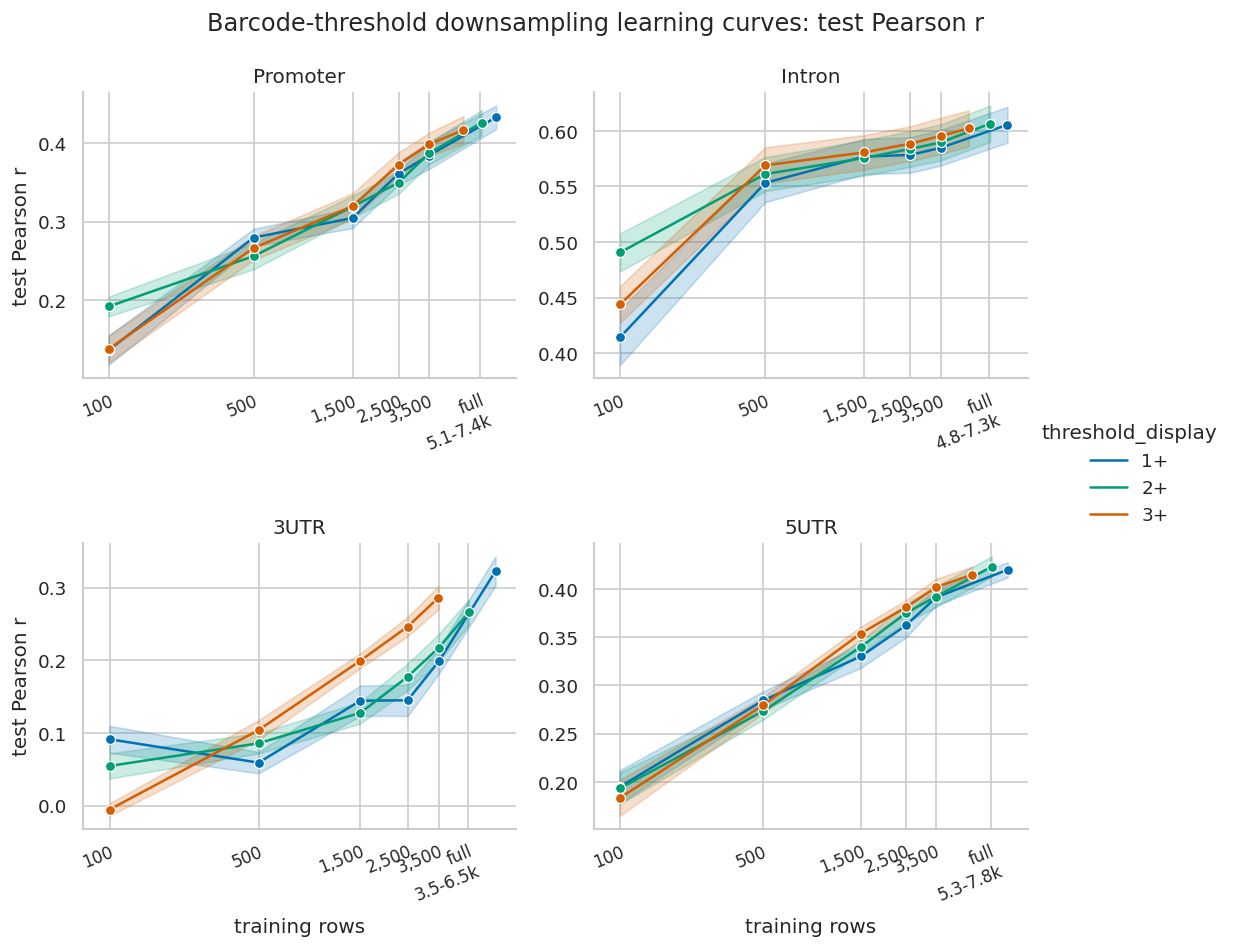

saved: /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretrain_CRE_inhouse_data/plots/lib1_barcode_threshold_downsample_june2026/figures/learning_curve_val_pearson.png


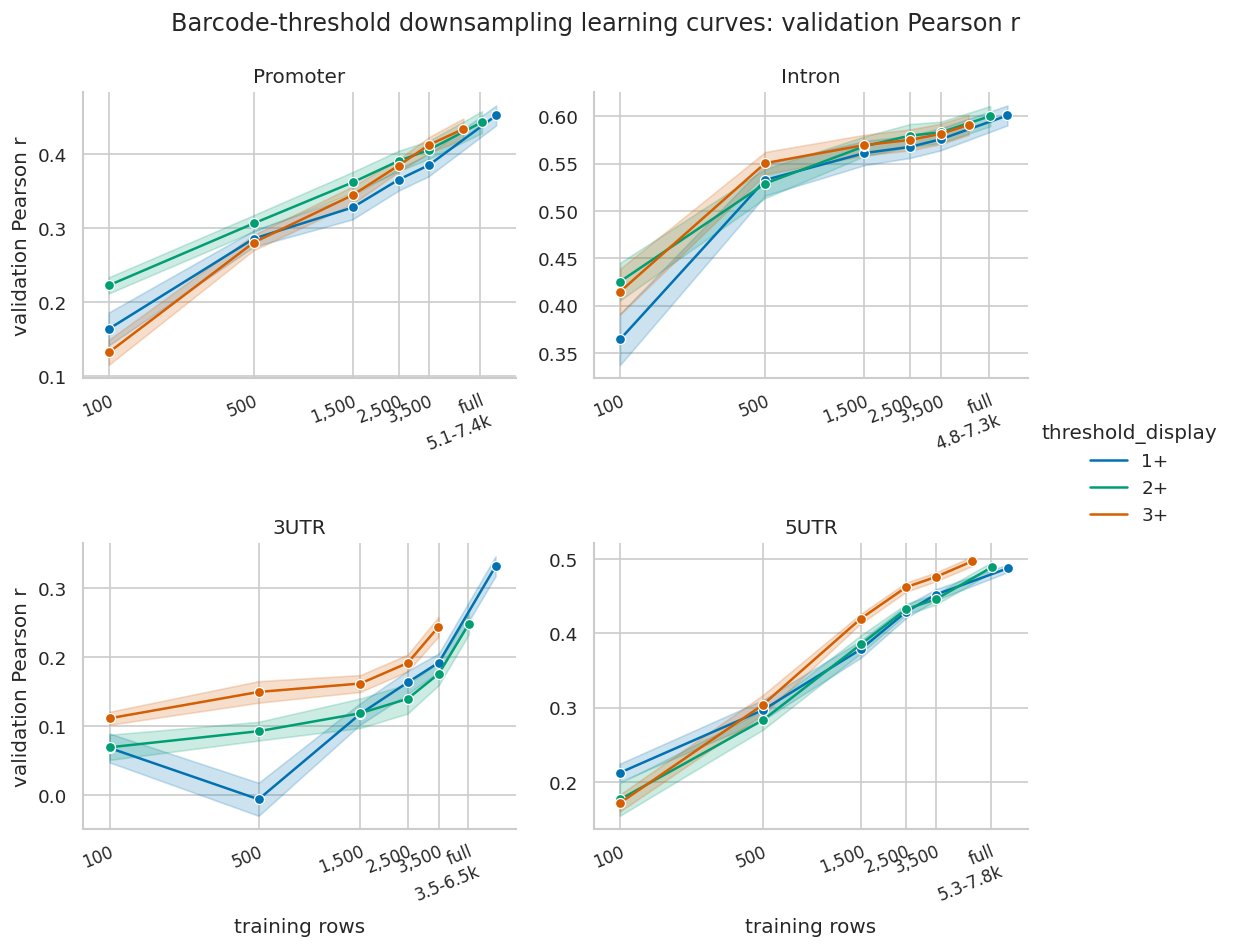

saved: /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretrain_CRE_inhouse_data/plots/lib1_barcode_threshold_downsample_june2026/figures/learning_curve_train_pearson.png


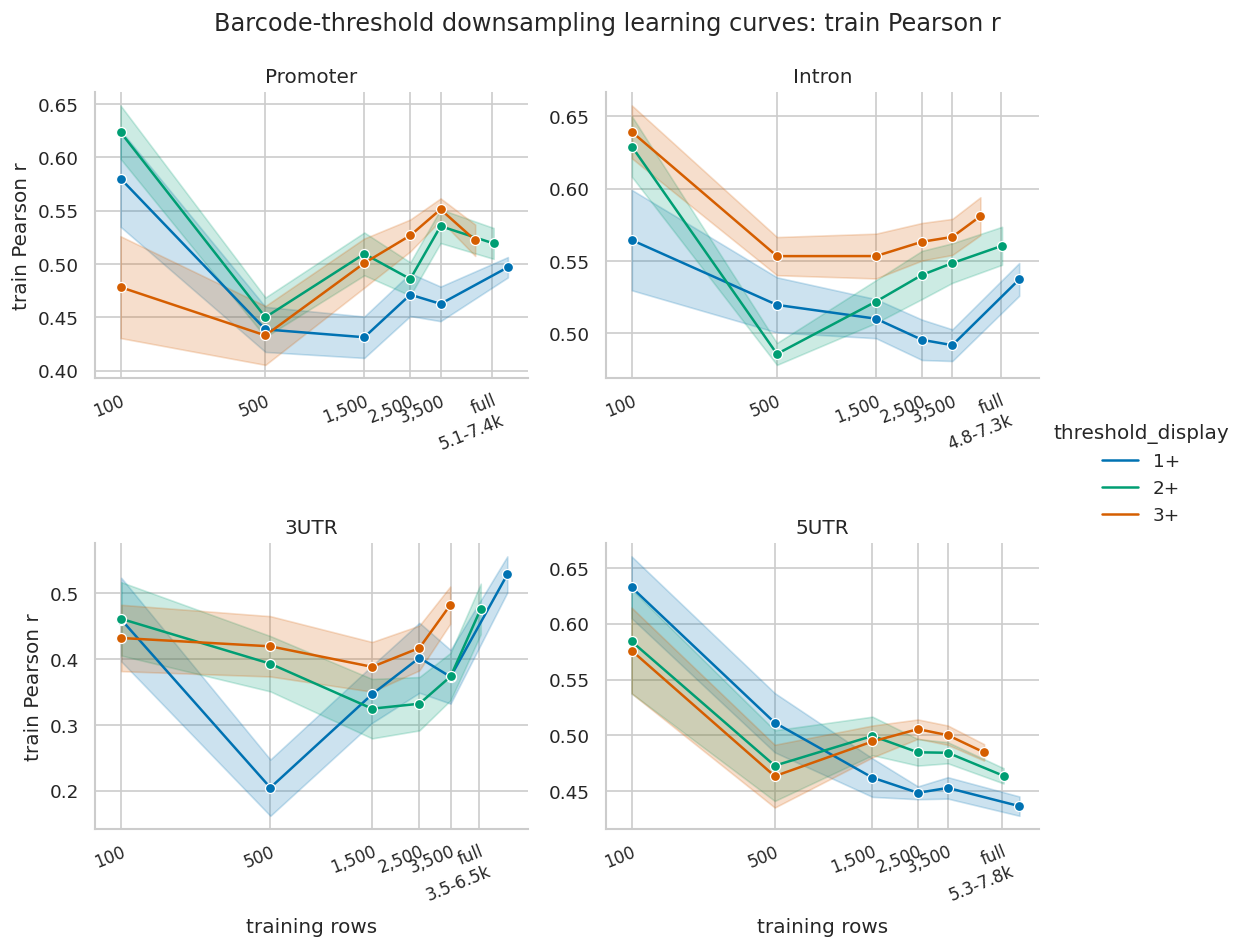

In [5]:
def plot_learning_curves(frame: pd.DataFrame, metric: str, *, split_label: str, filename: str | None = None):
    plot_df = frame[np.isfinite(pd.to_numeric(frame[metric], errors="coerce"))].copy()
    if not require_rows(plot_df, f"learning curve {metric}"):
        return None
    n_parts = plot_df["part"].nunique()
    col_wrap = min(2, max(1, n_parts))
    g = sns.relplot(
        data=plot_df,
        x="train_size_x",
        y=metric,
        hue="threshold_display",
        col="part",
        col_wrap=col_wrap,
        kind="line",
        marker="o",
        estimator="mean",
        errorbar="se",
        height=3.6,
        aspect=1.25,
        palette=THRESHOLD_PALETTE,
        facet_kws={"sharex": False, "sharey": False},
    )
    for ax, part in zip(g.axes.flat, facet_values(g, "col")):
        apply_size_axis(ax, plot_df[plot_df["part"].astype(str).eq(part)])
    g.set_ylabels(split_label)
    g.set_titles("{col_name}")
    g.fig.suptitle(f"Barcode-threshold downsampling learning curves: {split_label}", y=1.04)
    finalize_facet_grid(g)
    if filename and SAVE_FIGURES:
        g.fig.savefig(FIG_DIR / filename, bbox_inches="tight", dpi=180)
        print(f"saved: {FIG_DIR / filename}")
    return g

for metric, label in [("test_pearson", "test Pearson r"), ("val_pearson", "validation Pearson r"), ("train_pearson", "train Pearson r")]:
    if metric in runs.columns:
        g = plot_learning_curves(runs, metric, split_label=label, filename=f"learning_curve_{metric}.png")
        plt.show()


## Marginal Gain and Target-0.7 Extrapolation

Your wording is mostly accurate with one precision tweak: because the x-axis is log-scaled, Promoter and 5UTR are better described as approximately log-linear learning curves, or roughly constant Test Pearson-r gain per 10x more variants, rather than linear in raw variant count.

Using the part-level semi-log model

```text
r(N) = a + b * log10(N)
```

where `N` is training variants/rows and `b` is the Test Pearson-r gain per 10x more variants:

```text
N_target = 10 ** ((0.70 - a) / b)
additional variants = max(0, N_target - N_current)
```

Current estimates from the completed run set:

| Part | plot-language call | marginal gain per 10x (`b`) | best observed Test r | current max N | estimated total N for Test r = 0.70 | additional variants |
|---|---|---:|---:|---:|---:|---:|
| Promoter | approximately log-linear / near-constant per-10x gain | 0.149 | 0.433 | 7,393 | 465,530 | 458,137 |
| Intron | plateauing after the early 100-to-500 jump | 0.081 | 0.607 | 7,348 | 63,918 | 56,570 |
| 3UTR | concave up / accelerating | 0.132 | 0.323 | 6,457 | 13,480,929 | 13,474,472 |
| 5UTR | approximately log-linear / near-constant per-10x gain | 0.129 | 0.423 | 7,831 | 898,625 | 890,794 |

Interpretation caveat: these are extrapolations beyond the observed training sizes. A quadratic curvature check gives a more shape-sensitive sensitivity analysis: Promoter about 267,840 total variants, Intron no 0.70 crossing under the plateauing fit, 3UTR about 64,946 total variants because the tail accelerates, and 5UTR about 1,816,691 total variants. I would cite the semi-log table as the simple back-of-envelope estimate and cite the curvature check as the uncertainty range, especially for Intron and 3UTR.


In [ ]:
TARGET_TEST_PEARSON = 0.70
TARGET_METRIC = "test_pearson"

SHAPE_CALLS = {
    "Promoter": "approximately log-linear / near-constant per-10x gain",
    "Intron": "plateauing after the early 100-to-500 jump",
    "3UTR": "concave up / accelerating",
    "5UTR": "approximately log-linear / near-constant per-10x gain",
}


def _learning_curve_means(frame: pd.DataFrame, metric: str) -> pd.DataFrame:
    metric_values = pd.to_numeric(frame[metric], errors="coerce")
    train_sizes = pd.to_numeric(frame["train_size_x"], errors="coerce")
    mask = metric_values.notna() & train_sizes.notna() & train_sizes.gt(0)
    curve_df = frame.loc[mask].copy()
    curve_df[metric] = metric_values.loc[curve_df.index]
    curve_df["train_size_x"] = train_sizes.loc[curve_df.index]

    means = (
        curve_df.groupby(["part", "threshold_display", "train_size_label"], observed=True)
        .agg(
            train_size_x=("train_size_x", geometric_mean),
            metric_mean=(metric, "mean"),
            replicate_n=(metric, "size"),
        )
        .reset_index()
        .dropna(subset=["train_size_x", "metric_mean"])
    )
    means["part"] = pd.Categorical(means["part"].astype(str), categories=PART_ORDER, ordered=True)
    return means.sort_values(["part", "threshold_display", "train_size_x"], kind="stable")


def _r_squared(y: np.ndarray, yhat: np.ndarray) -> float:
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    if ss_tot <= 0:
        return np.nan
    ss_res = float(np.sum((y - yhat) ** 2))
    return 1.0 - ss_res / ss_tot


def _target_n_from_semilog(intercept: float, slope: float, target: float) -> float:
    if not np.isfinite(intercept) or not np.isfinite(slope) or slope <= 0:
        return np.nan
    return float(10 ** ((target - intercept) / slope))


def _target_n_from_quadratic(c0: float, c1: float, c2: float, current_log10_n: float, target: float) -> float:
    if not np.all(np.isfinite([c0, c1, c2, current_log10_n])):
        return np.nan
    if abs(c2) < 1e-12:
        return _target_n_from_semilog(c0, c1, target)
    roots = np.roots([c2, c1, c0 - target])
    future_roots = [root.real for root in roots if abs(root.imag) < 1e-9 and root.real >= current_log10_n]
    if not future_roots:
        return np.nan
    return float(10 ** min(future_roots))


def _signed_term(value: float, variable: str) -> str:
    sign = "+" if value >= 0 else "-"
    return f" {sign} {abs(value):.3f} * {variable}"


def _format_count(value: float) -> str:
    if not np.isfinite(value):
        return "no crossing"
    return f"{value:,.0f}"


def _fit_part_target(sub: pd.DataFrame, target: float) -> dict[str, object]:
    x = np.log10(sub["train_size_x"].to_numpy(dtype=float))
    y = sub["metric_mean"].to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    yhat = intercept + slope * x

    current_idx = sub["train_size_x"].astype(float).idxmax()
    current_n = float(sub.loc[current_idx, "train_size_x"])
    current_test_r = float(sub.loc[current_idx, "metric_mean"])
    best_idx = sub["metric_mean"].astype(float).idxmax()
    best_test_r = float(sub.loc[best_idx, "metric_mean"])
    best_threshold = str(sub.loc[best_idx, "threshold_display"])
    best_size_label = str(sub.loc[best_idx, "train_size_label"])

    semilog_target_n = _target_n_from_semilog(intercept, slope, target)
    current_log10_n = np.log10(current_n)

    c0 = c1 = c2 = quadratic_r2 = quadratic_target_n = quadratic_current_gain = np.nan
    if len(np.unique(x)) >= 3:
        c2, c1, c0 = np.polyfit(x, y, 2)
        quadratic_yhat = c0 + c1 * x + c2 * x**2
        quadratic_r2 = _r_squared(y, quadratic_yhat)
        quadratic_current_gain = c1 + 2 * c2 * current_log10_n
        quadratic_target_n = _target_n_from_quadratic(c0, c1, c2, current_log10_n, target)

    return {
        "part": str(sub["part"].iloc[0]),
        "shape_call": SHAPE_CALLS.get(str(sub["part"].iloc[0]), ""),
        "semilog_intercept": intercept,
        "semilog_gain_per_10x": slope,
        "semilog_r2": _r_squared(y, yhat),
        "semilog_equation": f"r = {intercept:.3f}{_signed_term(slope, 'log10(N)')}",
        "current_max_train_rows": current_n,
        "test_r_at_current_max_n": current_test_r,
        "best_observed_test_r": best_test_r,
        "best_observed_threshold": best_threshold,
        "best_observed_train_size_label": best_size_label,
        "semilog_total_rows_for_0p70": semilog_target_n,
        "semilog_additional_variants": semilog_target_n - current_n if np.isfinite(semilog_target_n) else np.nan,
        "quadratic_c0": c0,
        "quadratic_c1": c1,
        "quadratic_c2": c2,
        "quadratic_current_gain_per_10x": quadratic_current_gain,
        "quadratic_r2": quadratic_r2,
        "quadratic_equation": f"r = {c0:.3f}{_signed_term(c1, 'log10(N)')}{_signed_term(c2, '[log10(N)]^2')}" if np.isfinite(c0) else "",
        "quadratic_total_rows_for_0p70": quadratic_target_n,
        "quadratic_additional_variants": quadratic_target_n - current_n if np.isfinite(quadratic_target_n) else np.nan,
    }


def _recent_gain_per_10x(curve_means: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (part, threshold), sub in curve_means.groupby(["part", "threshold_display"], observed=True):
        sub = sub.sort_values("train_size_x", kind="stable")
        if len(sub) < 2:
            continue
        prev = sub.iloc[-2]
        curr = sub.iloc[-1]
        log_jump = np.log10(float(curr["train_size_x"]) / float(prev["train_size_x"]))
        if log_jump <= 0:
            continue
        rows.append({
            "part": str(part),
            "threshold_display": str(threshold),
            "recent_gain_per_10x": (float(curr["metric_mean"]) - float(prev["metric_mean"])) / log_jump,
        })
    recent = pd.DataFrame(rows)
    if recent.empty:
        return pd.DataFrame(columns=["part", "recent_gain_per_10x"])
    return recent.groupby("part", as_index=False)["recent_gain_per_10x"].mean()


learning_curve_means = _learning_curve_means(runs, TARGET_METRIC)
learning_curve_target_summary = pd.DataFrame(
    [_fit_part_target(sub, TARGET_TEST_PEARSON) for _, sub in learning_curve_means.groupby("part", observed=True, sort=False)]
)
learning_curve_target_summary = learning_curve_target_summary.merge(
    _recent_gain_per_10x(learning_curve_means), on="part", how="left"
)
learning_curve_target_summary["part"] = pd.Categorical(
    learning_curve_target_summary["part"], categories=PART_ORDER, ordered=True
)
learning_curve_target_summary = learning_curve_target_summary.sort_values("part", kind="stable")
learning_curve_target_summary["part"] = learning_curve_target_summary["part"].astype(str)

semilog_display_cols = [
    "part", "shape_call", "semilog_gain_per_10x", "recent_gain_per_10x", "semilog_r2",
    "best_observed_test_r", "best_observed_threshold", "best_observed_train_size_label",
    "current_max_train_rows", "semilog_total_rows_for_0p70", "semilog_additional_variants",
    "semilog_equation",
]
semilog_display = learning_curve_target_summary[semilog_display_cols].copy()
for col in ["semilog_gain_per_10x", "recent_gain_per_10x", "semilog_r2", "best_observed_test_r"]:
    semilog_display[col] = semilog_display[col].round(3)
for col in ["current_max_train_rows", "semilog_total_rows_for_0p70", "semilog_additional_variants"]:
    semilog_display[col] = semilog_display[col].map(_format_count)

display(Markdown("### Semi-log marginal gain and target-0.7 estimate"))
display(semilog_display)

curvature_display_cols = [
    "part", "quadratic_current_gain_per_10x", "quadratic_r2",
    "quadratic_total_rows_for_0p70", "quadratic_additional_variants", "quadratic_equation",
]
curvature_display = learning_curve_target_summary[curvature_display_cols].copy()
for col in ["quadratic_current_gain_per_10x", "quadratic_r2"]:
    curvature_display[col] = curvature_display[col].round(3)
for col in ["quadratic_total_rows_for_0p70", "quadratic_additional_variants"]:
    curvature_display[col] = curvature_display[col].map(_format_count)

display(Markdown("### Quadratic curvature sensitivity check"))
display(curvature_display)

summary_path = TABLE_DIR / "part_level_learning_curve_target_0p70_summary.csv"
learning_curve_target_summary.to_csv(summary_path, index=False)
print(f"saved: {summary_path}")


## Train, Validation, and Test Curves Together

This is useful for seeing whether marginal gains are true heldout gains or mostly train-fit gains.


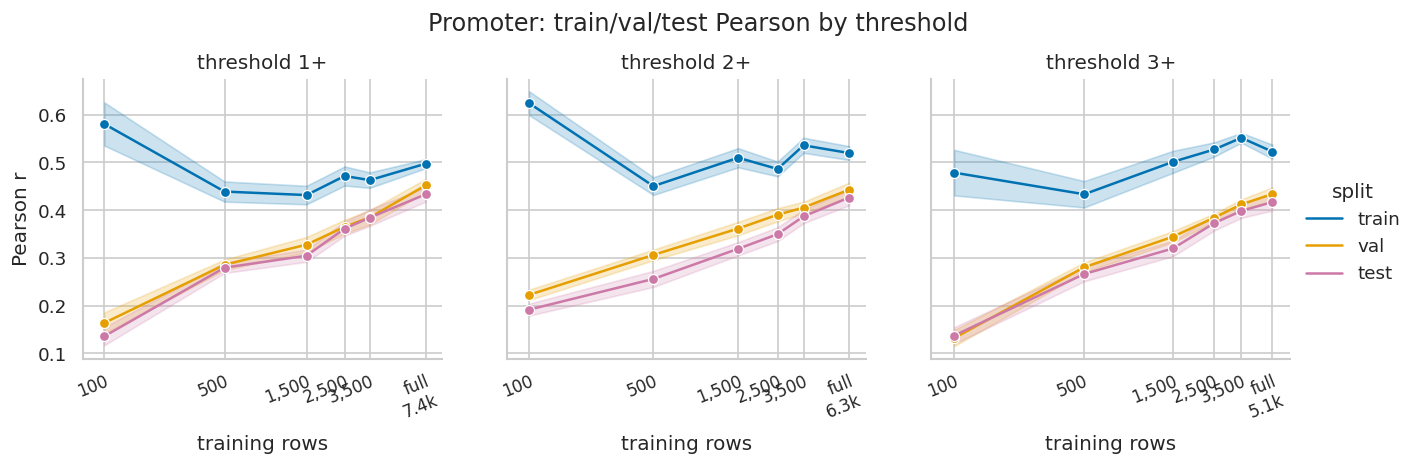

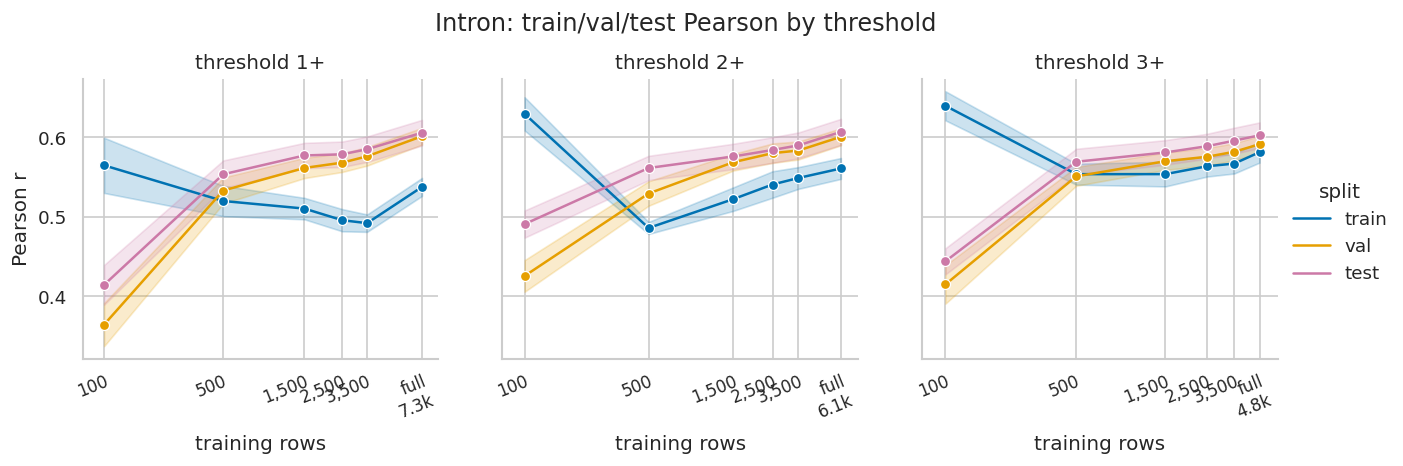

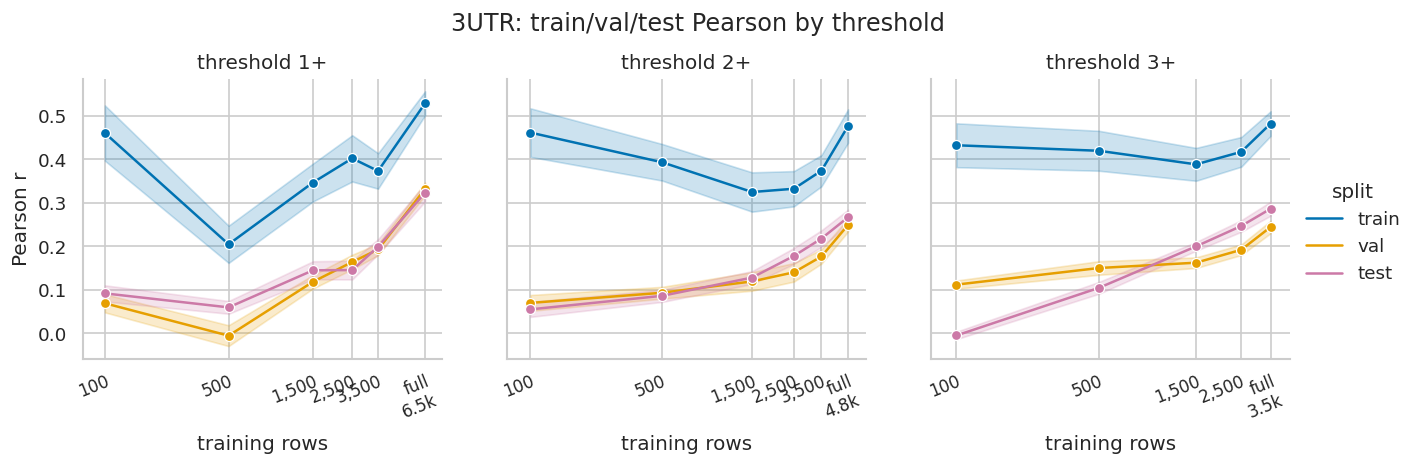

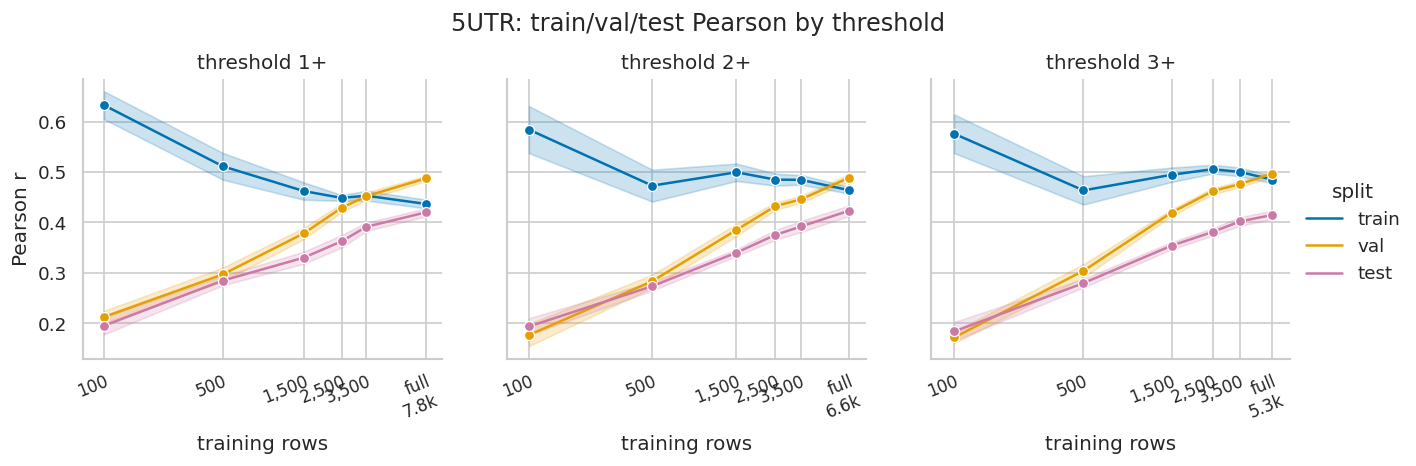

In [6]:
curve_long_parts = []
for split, col in METRIC_SPECS["pearson"]["cols"].items():
    if col in runs.columns:
        tmp = runs[["part", "config_id", "split_seed", "threshold_display", "barcode_threshold_label", "train_size_label", "train_size_x", col]].copy()
        tmp = tmp.rename(columns={col: "pearson"})
        tmp["split"] = split
        curve_long_parts.append(tmp)
pearson_long = pd.concat(curve_long_parts, ignore_index=True) if curve_long_parts else pd.DataFrame()
pearson_long = pearson_long[np.isfinite(pd.to_numeric(pearson_long.get("pearson"), errors="coerce"))].copy()

if require_rows(pearson_long, "train/val/test Pearson curves"):
    for part in pearson_long["part"].dropna().astype(str).unique():
        sub = pearson_long[pearson_long["part"].astype(str).eq(part)].copy()
        g = sns.relplot(
            data=sub,
            x="train_size_x",
            y="pearson",
            hue="split",
            col="threshold_display",
            kind="line",
            marker="o",
            estimator="mean",
            errorbar="se",
            height=3.4,
            aspect=1.08,
            palette=SPLIT_PALETTE,
            facet_kws={"sharex": False, "sharey": True},
        )
        for ax, threshold in zip(g.axes.flat, facet_values(g, "col")):
            apply_size_axis(ax, sub[sub["threshold_display"].astype(str).eq(threshold)])
        g.set_ylabels("Pearson r")
        g.set_titles("threshold {col_name}")
        g.fig.suptitle(f"{part}: train/val/test Pearson by threshold", y=1.05)
        finalize_facet_grid(g)
        if SAVE_FIGURES:
            g.fig.savefig(FIG_DIR / f"{part}_train_val_test_pearson_curves.png", bbox_inches="tight", dpi=180)
        plt.show()


## Matched Threshold Deltas

For each matched slice, compute threshold-policy deltas:

```text
2+ minus 1+
3+ minus 1+
3+ minus 2+
```

Positive values mean the stricter barcode threshold did better at the same config, split seed, and training-size label.


### Paired threshold deltas summary

,part,train_size_label,train_size_x,contrast,delta_metric_mean,delta_metric_std,delta_metric_se,delta_metric_n
3,3UTR,n100,100.000000,2+ minus 1+,-0.036726,0.121049,0.024210,25
15,3UTR,n500,500.000000,2+ minus 1+,0.026615,0.069500,0.013900,25
6,3UTR,n1500,1500.000000,2+ minus 1+,-0.016733,0.100151,0.020030,25
9,3UTR,n2500,2500.000000,2+ minus 1+,0.032489,0.116128,0.023226,25
12,3UTR,n3500,3500.000000,2+ minus 1+,0.018756,0.117326,0.023465,25
0,3UTR,full,4777.426169,2+ minus 1+,-0.056455,0.112173,0.022435,25
4,3UTR,n100,100.000000,3+ minus 1+,-0.096754,0.088729,0.017746,25
16,3UTR,n500,500.000000,3+ minus 1+,0.044879,0.085249,0.017050,25
7,3UTR,n1500,1500.000000,3+ minus 1+,0.055053,0.107855,0.021571,25
10,3UTR,n2500,2500.000000,3+ minus 1+,0.101443,0.108025,0.021605,25


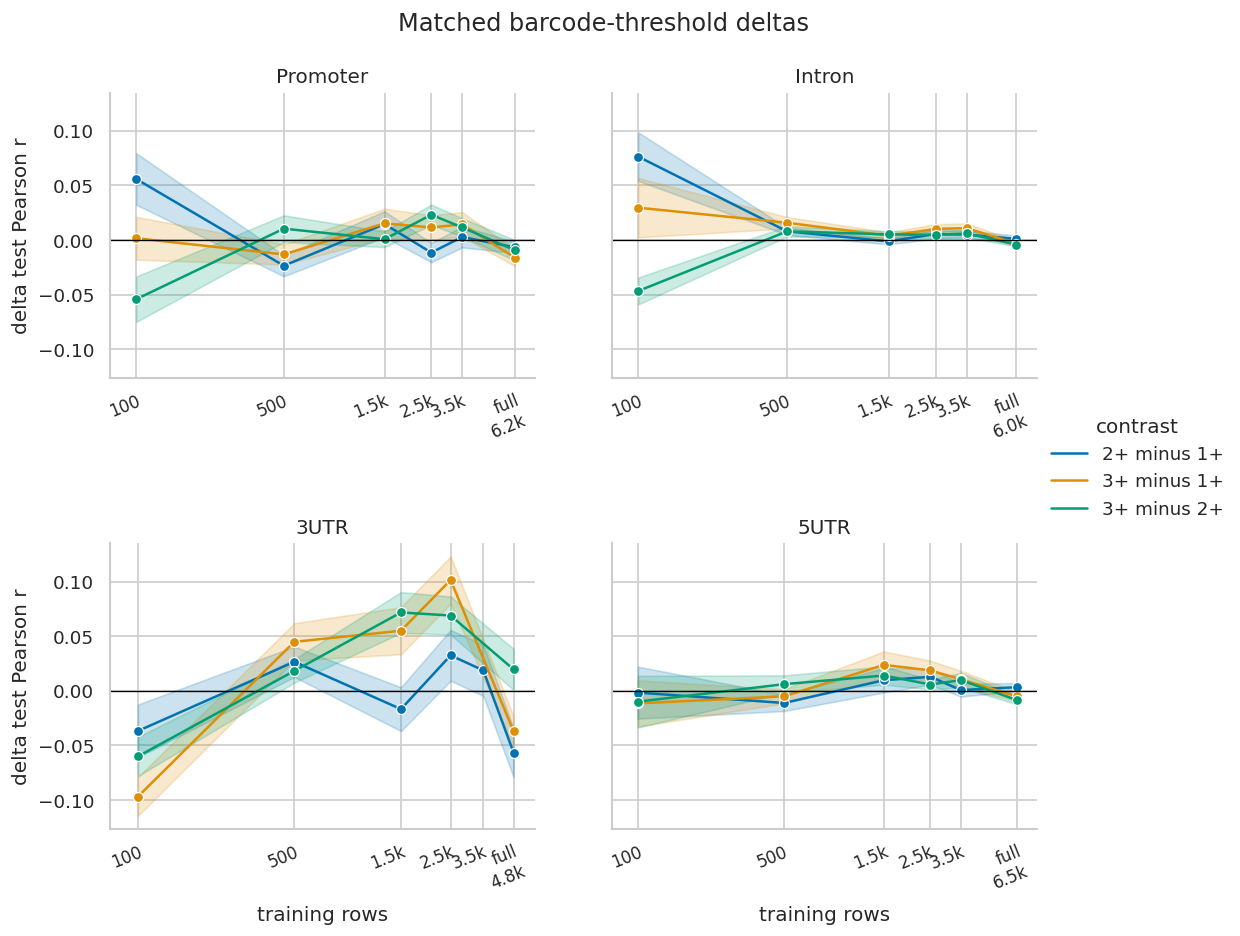

In [7]:
def paired_threshold_deltas(frame: pd.DataFrame, metric: str = "test_pearson") -> pd.DataFrame:
    key_cols = ["part", "config_id", "split_seed", "train_size_label"]
    wide = (
        frame.pivot_table(index=key_cols, columns="barcode_threshold_label", values=metric, aggfunc="first", observed=True)
        .reset_index()
    )
    size_axis = (
        frame.groupby(["part", "train_size_label"], observed=True)["train_size_x"]
        .apply(geometric_mean)
        .reset_index()
    )
    rows = []
    contrasts = [("bc_ge2", "bc_ge1", "2+ minus 1+"), ("bc_ge3", "bc_ge1", "3+ minus 1+"), ("bc_ge3", "bc_ge2", "3+ minus 2+")]
    for hi, lo, label in contrasts:
        if hi not in wide.columns or lo not in wide.columns:
            continue
        tmp = wide[key_cols + [hi, lo]].copy()
        tmp["contrast"] = label
        tmp["delta"] = tmp[hi] - tmp[lo]
        tmp["metric"] = metric
        tmp = tmp.merge(size_axis, on=["part", "train_size_label"], how="left")
        rows.append(tmp[key_cols + ["train_size_x", "contrast", "metric", "delta"]])
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

threshold_deltas = paired_threshold_deltas(runs, PRIMARY_METRIC)

display(Markdown("### Paired threshold deltas summary"))
threshold_delta_summary = metric_summary(
    threshold_deltas.rename(columns={"delta": "delta_metric"}),
    ["part", "train_size_label", "train_size_x", "contrast"],
    ["delta_metric"],
).sort_values(["part", "contrast", "train_size_x"], kind="stable")
display(threshold_delta_summary)

if require_rows(threshold_deltas, "paired threshold deltas"):
    g = sns.relplot(
        data=threshold_deltas,
        x="train_size_x",
        y="delta",
        hue="contrast",
        col="part",
        col_wrap=min(2, threshold_deltas["part"].nunique()),
        kind="line",
        marker="o",
        estimator="mean",
        errorbar="se",
        height=3.6,
        aspect=1.25,
        facet_kws={"sharex": False, "sharey": True},
    )
    for ax, part in zip(g.axes.flat, facet_values(g, "col")):
        apply_size_axis(ax, threshold_deltas[threshold_deltas["part"].astype(str).eq(part)])
        ax.axhline(0, color="black", linewidth=0.8)
    g.set_ylabels(f"delta {PRIMARY_METRIC_LABEL}")
    g.set_titles("{col_name}")
    g.fig.suptitle("Matched barcode-threshold deltas", y=1.04)
    finalize_facet_grid(g)
    if SAVE_FIGURES:
        g.fig.savefig(FIG_DIR / "matched_threshold_deltas_test_pearson.png", bbox_inches="tight", dpi=180)
    plt.show()


## Training-Size Marginal Gains

For each threshold policy, compute the gain from moving to the next larger size arm:

```text
100 -> 500 -> 1500 -> 2500 -> 3500 -> full
```

This shows where additional data stops buying heldout performance.


### Size marginal gain summary

,part,threshold_display,from_size,to_size,from_size_x,to_size_x,transition,transition_x,gain_metric_mean,gain_metric_std,gain_metric_se,gain_metric_n
0,Promoter,1+,n100,n500,100.0,500.0,100 -> 500,223.606798,0.143563,0.123926,0.024785,25
4,Promoter,1+,n500,n1500,500.0,1500.0,"500 -> 1,500",866.025404,0.025051,0.053554,0.010711,25
1,Promoter,1+,n1500,n2500,1500.0,2500.0,"1,500 -> 2,500",1936.491673,0.056663,0.032518,0.006504,25
2,Promoter,1+,n2500,n3500,2500.0,3500.0,"2,500 -> 3,500",2958.039892,0.022939,0.041861,0.008372,25
3,Promoter,1+,n3500,full,3500.0,7393.0,"3,500 -> full",5086.796634,0.048838,0.036884,0.007377,25
5,Promoter,2+,n100,n500,100.0,500.0,100 -> 500,223.606798,0.064224,0.088837,0.017767,25
9,Promoter,2+,n500,n1500,500.0,1500.0,"500 -> 1,500",866.025404,0.063153,0.051712,0.010342,25
6,Promoter,2+,n1500,n2500,1500.0,2500.0,"1,500 -> 2,500",1936.491673,0.030582,0.031027,0.006205,25
7,Promoter,2+,n2500,n3500,2500.0,3500.0,"2,500 -> 3,500",2958.039892,0.037253,0.028345,0.005669,25
8,Promoter,2+,n3500,full,3500.0,6311.0,"3,500 -> full",4699.840423,0.039349,0.031959,0.006392,25


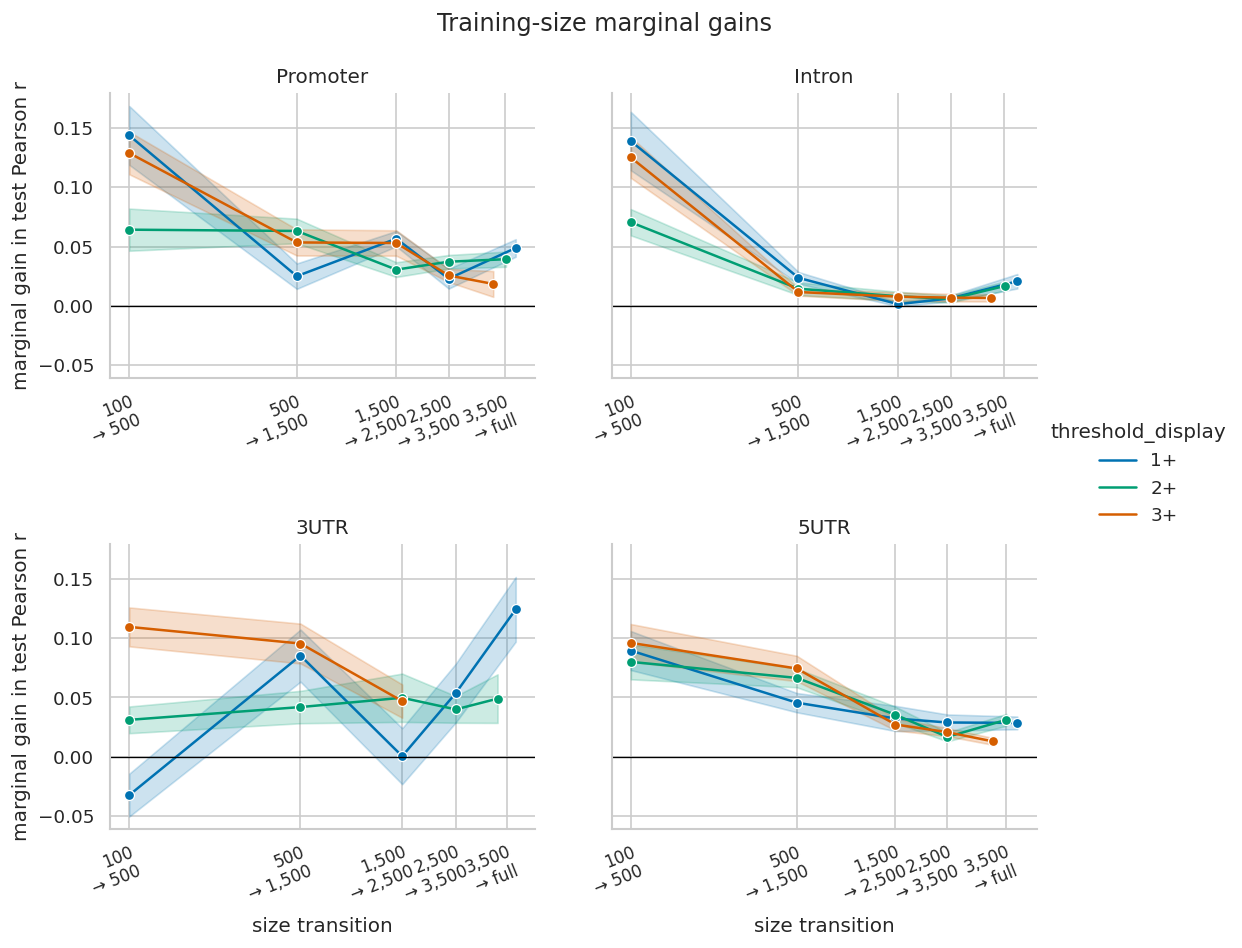

In [8]:
def paired_size_marginal_gains(frame: pd.DataFrame, metric: str = "test_pearson") -> pd.DataFrame:
    key_cols = ["part", "config_id", "split_seed", "barcode_threshold_label", "threshold_display"]
    metric_wide = (
        frame.pivot_table(index=key_cols, columns="train_size_label", values=metric, aggfunc="first", observed=True)
        .reset_index()
    )
    x_wide = (
        frame.pivot_table(index=key_cols, columns="train_size_label", values="train_size_x", aggfunc=geometric_mean, observed=True)
        .reset_index()
    )
    rows = []
    transitions = list(zip(SIZE_ORDER[:-1], SIZE_ORDER[1:]))
    for from_size, to_size in transitions:
        if from_size not in metric_wide.columns or to_size not in metric_wide.columns:
            continue
        tmp = metric_wide[key_cols + [from_size, to_size]].copy()
        tmp["from_size"] = from_size
        tmp["to_size"] = to_size
        tmp["transition"] = f"{SIZE_LABELS[from_size]} -> {SIZE_LABELS[to_size]}"
        tmp["gain"] = tmp[to_size] - tmp[from_size]
        tmp["metric"] = metric

        x_tmp = x_wide[key_cols + [from_size, to_size]].rename(
            columns={from_size: "from_size_x", to_size: "to_size_x"}
        )
        tmp = tmp.merge(x_tmp, on=key_cols, how="left")
        tmp["transition_x"] = np.sqrt(tmp["from_size_x"] * tmp["to_size_x"])
        rows.append(tmp[key_cols + ["from_size", "to_size", "from_size_x", "to_size_x", "transition", "transition_x", "metric", "gain"]])
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

size_gains = paired_size_marginal_gains(runs, PRIMARY_METRIC)
size_gain_summary = metric_summary(
    size_gains.rename(columns={"gain": "gain_metric"}),
    ["part", "threshold_display", "from_size", "to_size", "from_size_x", "to_size_x", "transition", "transition_x"],
    ["gain_metric"],
).sort_values(["part", "threshold_display", "transition_x"], kind="stable")

display(Markdown("### Size marginal gain summary"))
display(size_gain_summary)

if require_rows(size_gains, "training-size marginal gains"):
    g = sns.relplot(
        data=size_gains,
        x="transition_x",
        y="gain",
        hue="threshold_display",
        col="part",
        col_wrap=min(2, size_gains["part"].nunique()),
        kind="line",
        marker="o",
        estimator="mean",
        errorbar="se",
        height=3.6,
        aspect=1.25,
        palette=THRESHOLD_PALETTE,
        facet_kws={"sharex": False, "sharey": True},
    )
    for ax, part in zip(g.axes.flat, facet_values(g, "col")):
        apply_transition_axis(ax, size_gains[size_gains["part"].astype(str).eq(part)])
        ax.axhline(0, color="black", linewidth=0.8)
    g.set_ylabels(f"marginal gain in {PRIMARY_METRIC_LABEL}")
    g.set_titles("{col_name}")
    g.fig.suptitle("Training-size marginal gains", y=1.04)
    finalize_facet_grid(g)
    if SAVE_FIGURES:
        g.fig.savefig(FIG_DIR / "training_size_marginal_gains_test_pearson.png", bbox_inches="tight", dpi=180)
    plt.show()


## Full-Pool Delta Versus Best Exact-N Arm

This asks whether using every eligible row beats the best fixed-size arm under the same threshold/config/split.


### Full minus best exact-N summary

,part,threshold_display,best_exact_size,delta_metric_mean,delta_metric_std,delta_metric_se,delta_metric_n,full_metric_mean,full_metric_std,full_metric_se,full_metric_n,best_exact_metric_mean,best_exact_metric_std,best_exact_metric_se,best_exact_metric_n
0,Promoter,1+,n2500,0.052229,0.023289,0.009508,6,0.368182,0.057654,0.023537,6,0.315953,0.049807,0.020334,6
1,Promoter,1+,n3500,0.038136,0.033411,0.007665,19,0.453451,0.069378,0.015916,19,0.415316,0.065923,0.015124,19
2,Promoter,2+,n2500,0.027386,0.029386,0.013142,5,0.394962,0.097222,0.043479,5,0.367576,0.075828,0.033911,5
3,Promoter,2+,n3500,0.041135,0.032753,0.007324,20,0.434036,0.076937,0.017204,20,0.392901,0.070539,0.015773,20
4,Promoter,3+,n2500,0.024835,0.028182,0.012603,5,0.412209,0.103184,0.046145,5,0.387373,0.077524,0.034670,5
5,Promoter,3+,n3500,0.014071,0.058836,0.013156,20,0.417997,0.087555,0.019578,20,0.403926,0.072481,0.016207,20
6,Intron,1+,n100,0.005726,NaN,NaN,1,0.451127,NaN,NaN,1,0.445402,NaN,NaN,1
7,Intron,1+,n1500,0.004828,0.007286,0.003643,4,0.649765,0.051462,0.025731,4,0.644938,0.048939,0.024469,4
8,Intron,1+,n2500,0.024773,0.034363,0.015368,5,0.591069,0.094913,0.042446,5,0.566296,0.072790,0.032553,5
9,Intron,1+,n3500,0.020784,0.035106,0.009064,15,0.608855,0.075133,0.019399,15,0.588071,0.078175,0.020185,15


saved: /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretrain_CRE_inhouse_data/plots/lib1_barcode_threshold_downsample_june2026/figures/full_minus_best_exact_test_pearson.png


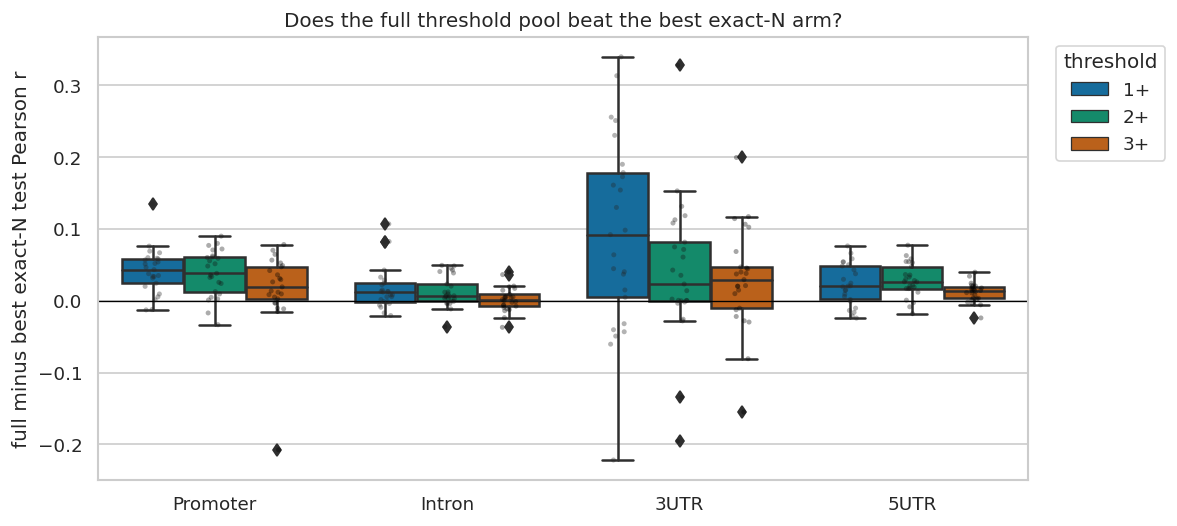

In [9]:
def full_vs_best_exact(frame: pd.DataFrame, metric: str = "test_pearson") -> pd.DataFrame:
    exact = frame[frame["train_size_label"].astype(str).ne("full")].copy()
    full = frame[frame["train_size_label"].astype(str).eq("full")].copy()
    key_cols = ["part", "config_id", "split_seed", "barcode_threshold_label", "threshold_display"]
    if exact.empty or full.empty:
        return pd.DataFrame()
    idx = exact.groupby(key_cols, observed=True)[metric].idxmax()
    best_exact = exact.loc[idx, key_cols + ["train_size_label", "train_size_x", metric]].rename(
        columns={"train_size_label": "best_exact_size", "train_size_x": "best_exact_size_x", metric: "best_exact_metric"}
    )
    full_metric = full[key_cols + [metric]].rename(columns={metric: "full_metric"})
    out = full_metric.merge(best_exact, on=key_cols, how="inner")
    out["full_minus_best_exact"] = out["full_metric"] - out["best_exact_metric"]
    out["metric"] = metric
    return out

full_delta = full_vs_best_exact(runs, PRIMARY_METRIC)
full_delta_summary = metric_summary(
    full_delta.rename(columns={"full_minus_best_exact": "delta_metric"}),
    ["part", "threshold_display", "best_exact_size"],
    ["delta_metric", "full_metric", "best_exact_metric"],
).sort_values(["part", "threshold_display", "best_exact_size"], kind="stable")

display(Markdown("### Full minus best exact-N summary"))
display(full_delta_summary)

if require_rows(full_delta, "full-pool delta"):
    plt.figure(figsize=(10, 4.8))
    ax = sns.boxplot(
        data=full_delta,
        x="part",
        y="full_minus_best_exact",
        hue="threshold_display",
        palette=THRESHOLD_PALETTE,
    )
    sns.stripplot(
        data=full_delta,
        x="part",
        y="full_minus_best_exact",
        hue="threshold_display",
        dodge=True,
        color="black",
        alpha=0.35,
        size=3,
        legend=False,
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel(f"full minus best exact-N {PRIMARY_METRIC_LABEL}")
    ax.set_xlabel("")
    ax.set_title("Does the full threshold pool beat the best exact-N arm?")
    plt.legend(title="threshold", bbox_to_anchor=(1.02, 1), loc="upper left")
    save_fig("full_minus_best_exact_test_pearson.png")
    plt.show()


## Validation/Test Agreement and Generalization Gaps

These checks mirror the HPO notebook: validation/test scatter tells us whether validation ranking is predictive; train-test gap tells us whether small-N or low-threshold arms are overfitting.


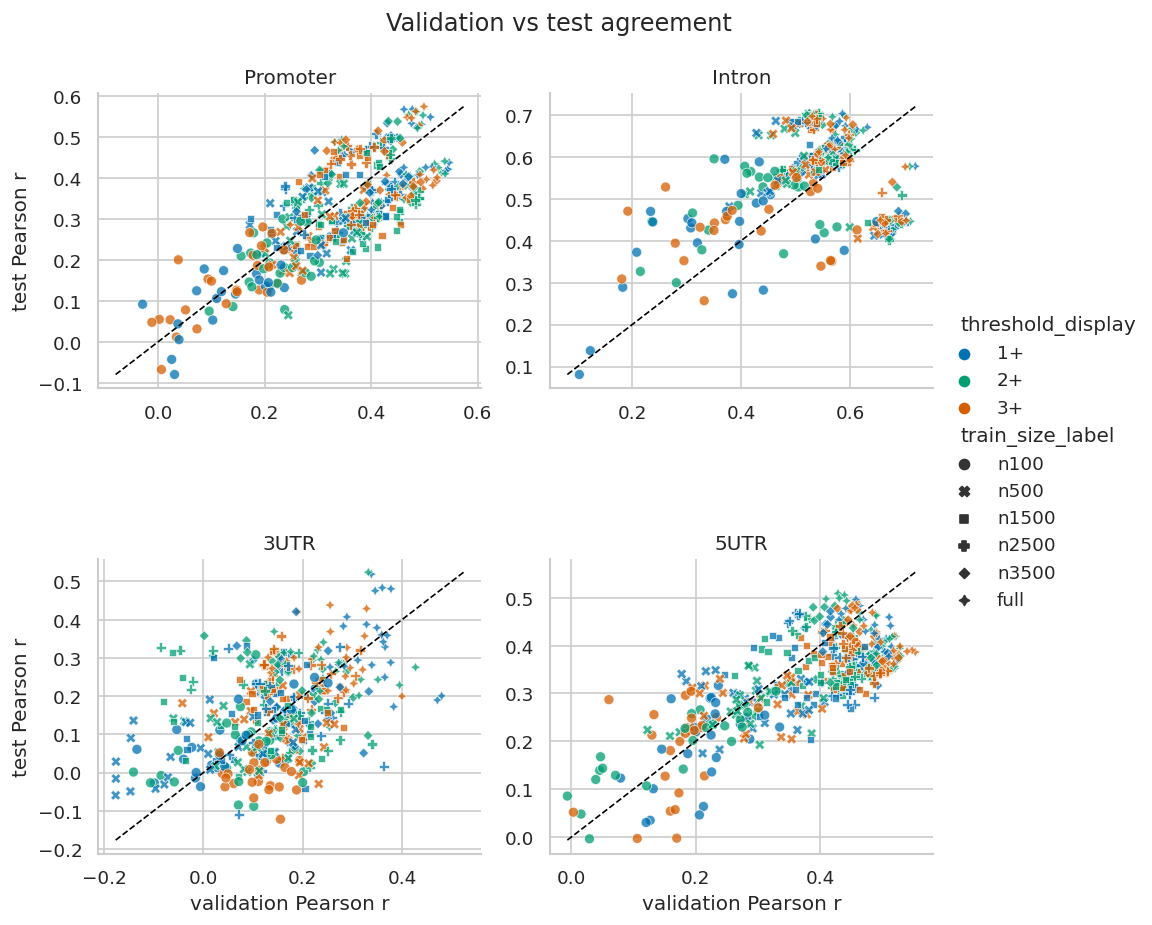

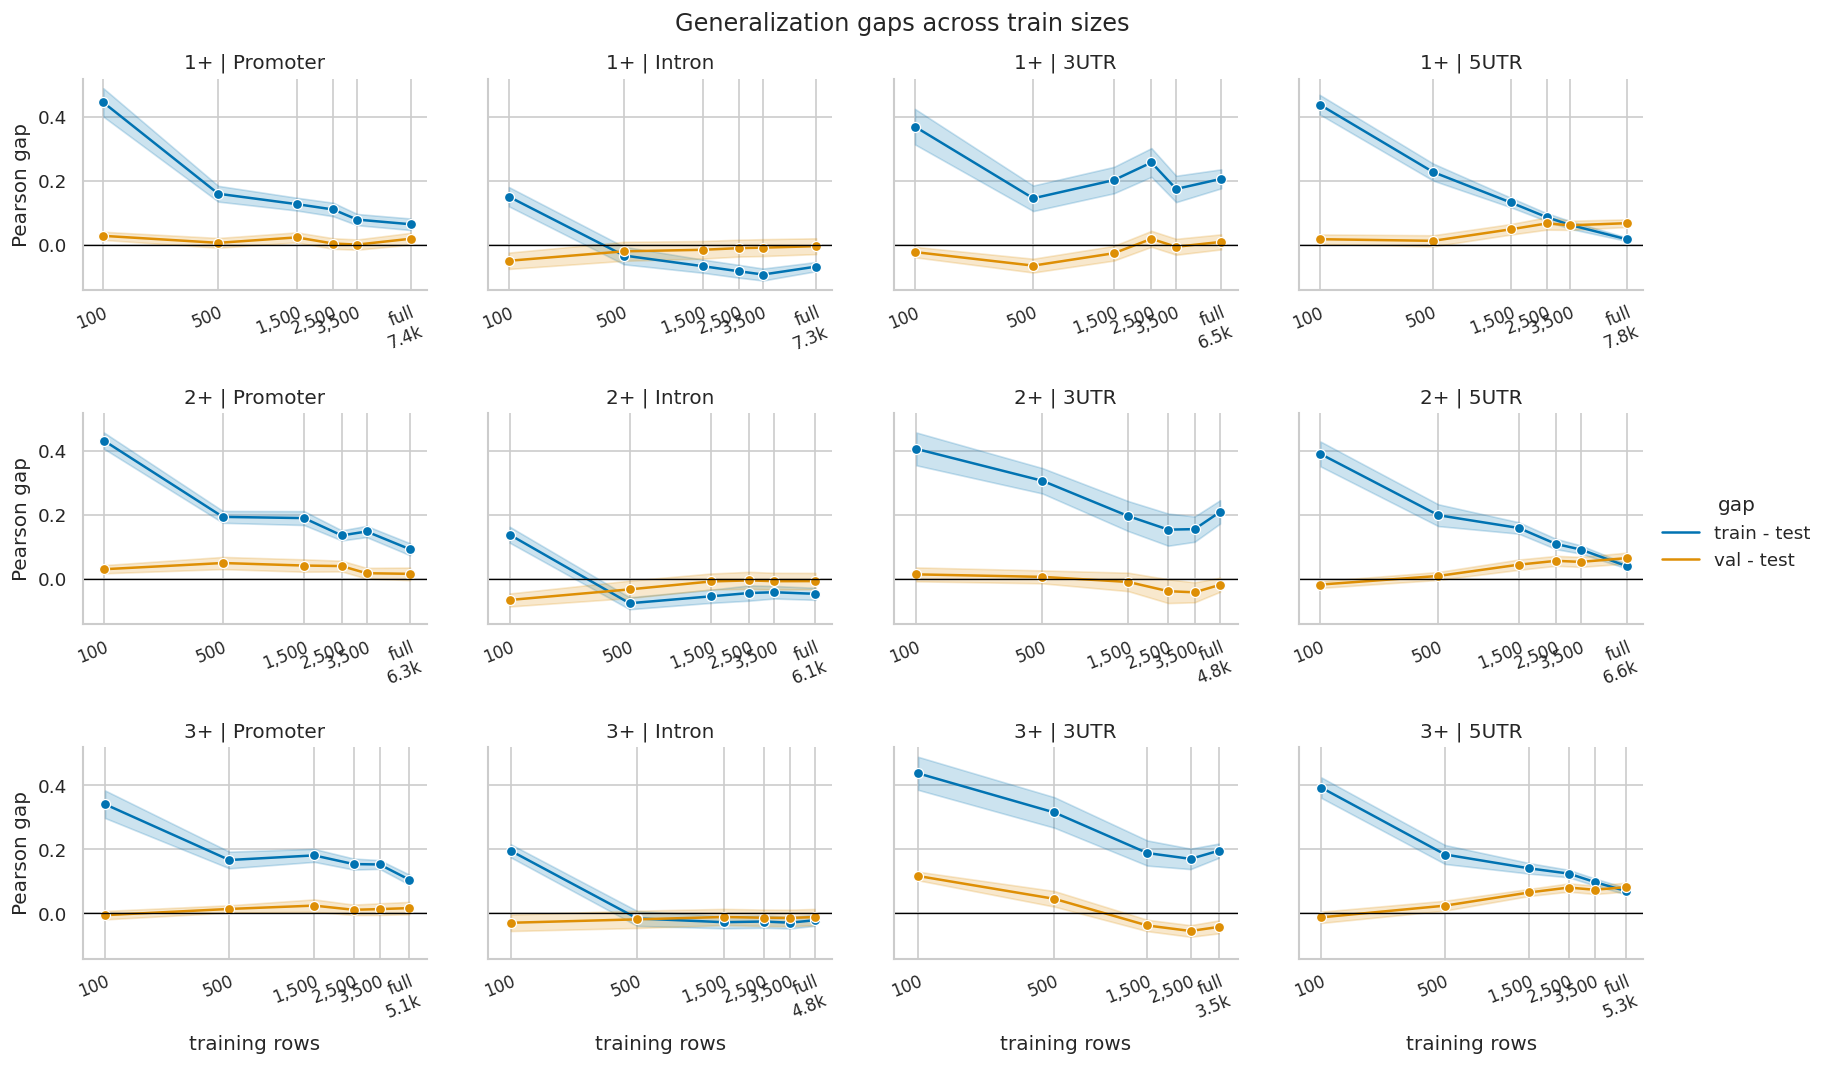

In [10]:
scatter_df = runs[np.isfinite(runs.get("val_pearson")) & np.isfinite(runs.get("test_pearson"))].copy()
if require_rows(scatter_df, "validation/test agreement"):
    g = sns.relplot(
        data=scatter_df,
        x="val_pearson",
        y="test_pearson",
        hue="threshold_display",
        style="train_size_label",
        col="part",
        col_wrap=min(2, scatter_df["part"].nunique()),
        kind="scatter",
        alpha=0.75,
        height=3.7,
        aspect=1.1,
        palette=THRESHOLD_PALETTE,
        facet_kws={"sharex": False, "sharey": False},
    )
    for ax, (_, sub) in zip(g.axes.flat, scatter_df.groupby("part", observed=True)):
        finite = np.isfinite(sub["val_pearson"]) & np.isfinite(sub["test_pearson"])
        if finite.any():
            lo = min(sub.loc[finite, "val_pearson"].min(), sub.loc[finite, "test_pearson"].min())
            hi = max(sub.loc[finite, "val_pearson"].max(), sub.loc[finite, "test_pearson"].max())
            ax.plot([lo, hi], [lo, hi], "--", color="black", linewidth=1)
    g.set_axis_labels("validation Pearson r", "test Pearson r")
    g.set_titles("{col_name}")
    g.fig.suptitle("Validation vs test agreement", y=1.04)
    finalize_facet_grid(g)
    if SAVE_FIGURES:
        g.fig.savefig(FIG_DIR / "validation_vs_test_pearson.png", bbox_inches="tight", dpi=180)
    plt.show()

gap_df = runs.copy()
gap_df["train_minus_test_pearson"] = gap_df["train_pearson"] - gap_df["test_pearson"]
gap_df["val_minus_test_pearson"] = gap_df["val_pearson"] - gap_df["test_pearson"]
gap_long = gap_df.melt(
    id_vars=["part", "config_id", "split_seed", "threshold_display", "train_size_label", "train_size_x"],
    value_vars=["train_minus_test_pearson", "val_minus_test_pearson"],
    var_name="gap",
    value_name="delta_pearson",
)
gap_long["gap"] = gap_long["gap"].map({
    "train_minus_test_pearson": "train - test",
    "val_minus_test_pearson": "val - test",
})
gap_long = gap_long[np.isfinite(pd.to_numeric(gap_long["delta_pearson"], errors="coerce"))]

if require_rows(gap_long, "generalization gaps"):
    g = sns.relplot(
        data=gap_long,
        x="train_size_x",
        y="delta_pearson",
        hue="gap",
        col="part",
        row="threshold_display" if gap_long["threshold_display"].nunique() > 1 else None,
        kind="line",
        marker="o",
        estimator="mean",
        errorbar="se",
        height=2.8,
        aspect=1.25,
        facet_kws={"sharex": False, "sharey": True},
    )
    if gap_long["threshold_display"].nunique() > 1:
        for (threshold, part), ax in g.axes_dict.items():
            sub = gap_long[
                gap_long["threshold_display"].astype(str).eq(str(threshold))
                & gap_long["part"].astype(str).eq(str(part))
            ]
            apply_size_axis(ax, sub)
            ax.axhline(0, color="black", linewidth=0.8)
    else:
        for ax, part in zip(g.axes.flat, facet_values(g, "col")):
            apply_size_axis(ax, gap_long[gap_long["part"].astype(str).eq(part)])
            ax.axhline(0, color="black", linewidth=0.8)
    g.set_ylabels("Pearson gap")
    g.set_titles("{row_name} | {col_name}" if gap_long["threshold_display"].nunique() > 1 else "{col_name}")
    g.fig.suptitle("Generalization gaps across train sizes", y=1.02)
    finalize_facet_grid(g)
    if SAVE_FIGURES:
        g.fig.savefig(FIG_DIR / "generalization_gaps_pearson.png", bbox_inches="tight", dpi=180)
    plt.show()


## Best Epoch and Early-Stopping Behavior

A quick check for whether smaller or noisier threshold pools need more epochs, or whether strict thresholds hit early stopping differently.


### Best epoch summary

,part,threshold_display,train_size_label,train_size_x,best_epoch_mean,best_epoch_std,best_epoch_se,best_epoch_n,test_pearson_mean,test_pearson_std,test_pearson_se,test_pearson_n
0,Promoter,1+,n100,100.0,71.96,44.061018,8.812204,25,0.135932,0.094028,0.018806,25
1,Promoter,1+,n500,500.0,70.16,57.599682,11.519936,25,0.279495,0.055617,0.011123,25
2,Promoter,1+,n1500,1500.0,63.92,45.067468,9.013494,25,0.304547,0.064188,0.012838,25
3,Promoter,1+,n2500,2500.0,92.80,52.655326,10.531065,25,0.361209,0.073701,0.014740,25
4,Promoter,1+,n3500,3500.0,79.24,39.521387,7.904277,25,0.384148,0.086138,0.017228,25
5,Promoter,1+,full,7393.0,117.00,42.629215,8.525843,25,0.432986,0.075392,0.015078,25
6,Promoter,2+,n100,100.0,81.12,54.758044,10.951609,25,0.191660,0.062804,0.012561,25
7,Promoter,2+,n500,500.0,62.92,55.929956,11.185991,25,0.255884,0.084008,0.016802,25
8,Promoter,2+,n1500,1500.0,88.56,46.716414,9.343283,25,0.319037,0.069746,0.013949,25
9,Promoter,2+,n2500,2500.0,102.12,64.146525,12.829305,25,0.349619,0.071898,0.014380,25


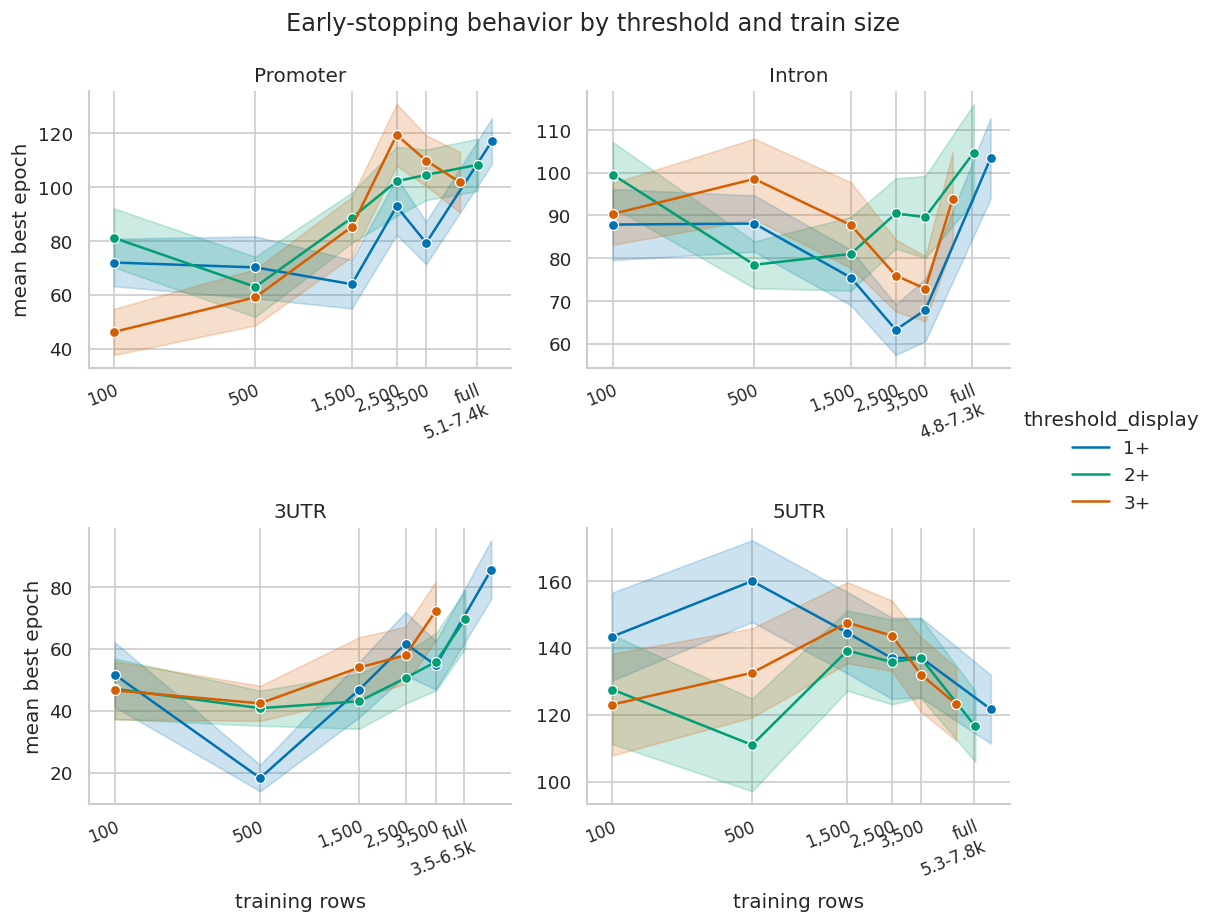

In [11]:
epoch_df = runs[np.isfinite(pd.to_numeric(runs.get("best_epoch"), errors="coerce"))].copy()
epoch_summary = metric_summary(
    epoch_df,
    ["part", "threshold_display", "train_size_label", "train_size_x"],
    ["best_epoch", "test_pearson"],
).sort_values(["part", "threshold_display", "train_size_x"], kind="stable")

display(Markdown("### Best epoch summary"))
display(epoch_summary)

if require_rows(epoch_df, "best epoch"):
    g = sns.relplot(
        data=epoch_df,
        x="train_size_x",
        y="best_epoch",
        hue="threshold_display",
        col="part",
        col_wrap=min(2, epoch_df["part"].nunique()),
        kind="line",
        marker="o",
        estimator="mean",
        errorbar="se",
        height=3.5,
        aspect=1.25,
        palette=THRESHOLD_PALETTE,
        facet_kws={"sharex": False, "sharey": False},
    )
    for ax, part in zip(g.axes.flat, facet_values(g, "col")):
        apply_size_axis(ax, epoch_df[epoch_df["part"].astype(str).eq(part)])
    g.set_ylabels("mean best epoch")
    g.set_titles("{col_name}")
    g.fig.suptitle("Early-stopping behavior by threshold and train size", y=1.04)
    finalize_facet_grid(g)
    if SAVE_FIGURES:
        g.fig.savefig(FIG_DIR / "best_epoch_by_threshold_size.png", bbox_inches="tight", dpi=180)
    plt.show()


## Config-Level Profiles

These plots keep each `config_id` visible. They help catch cases where the average threshold effect is driven by one hyperparameter setting.


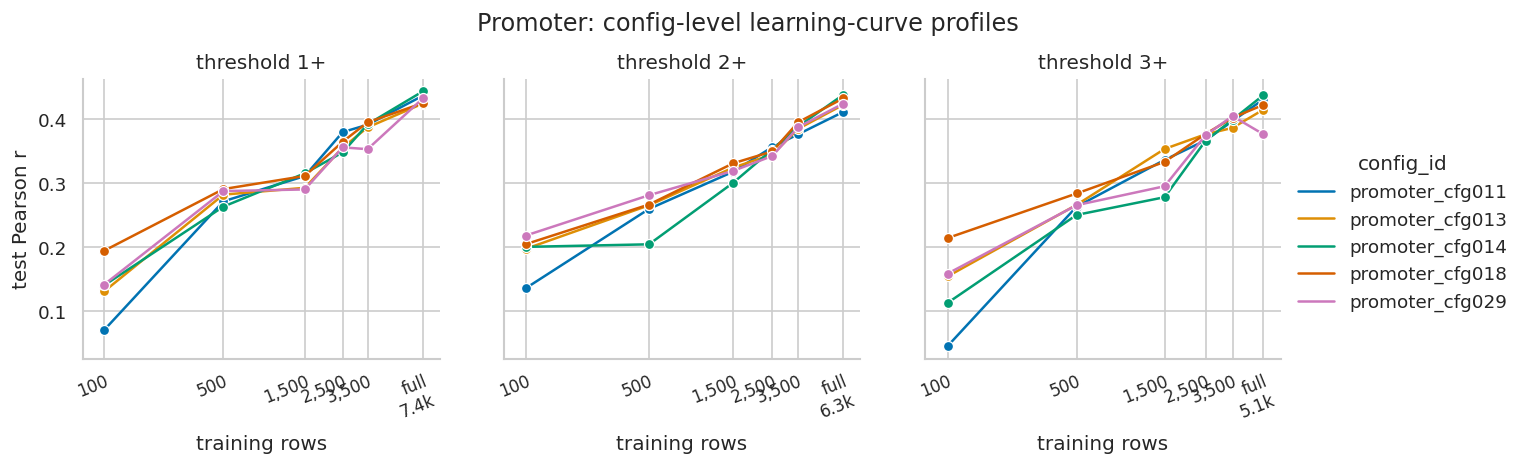

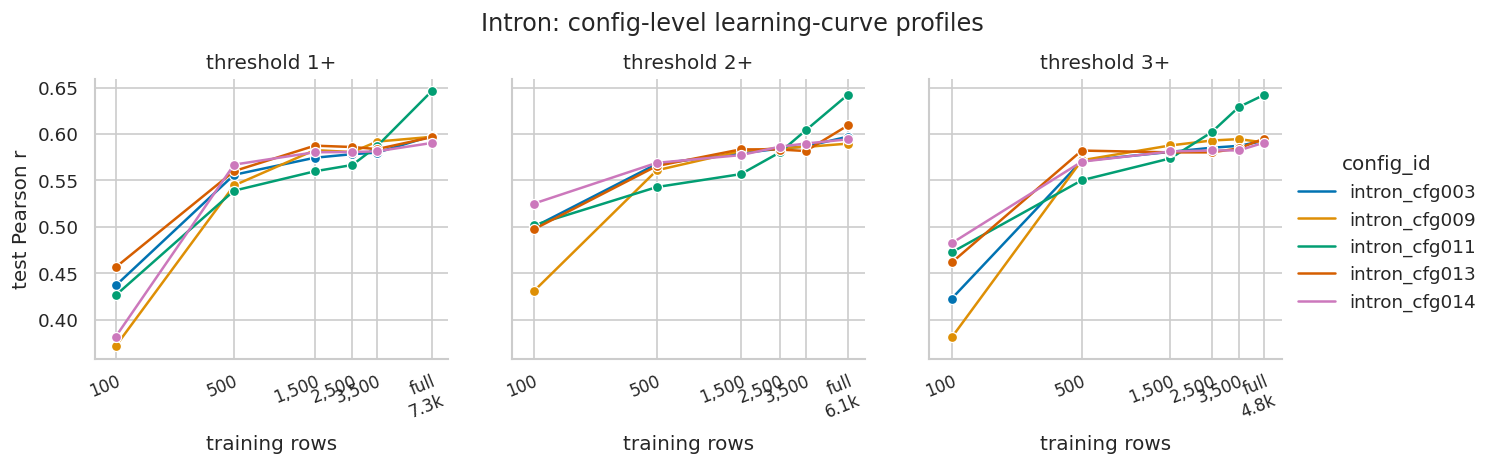

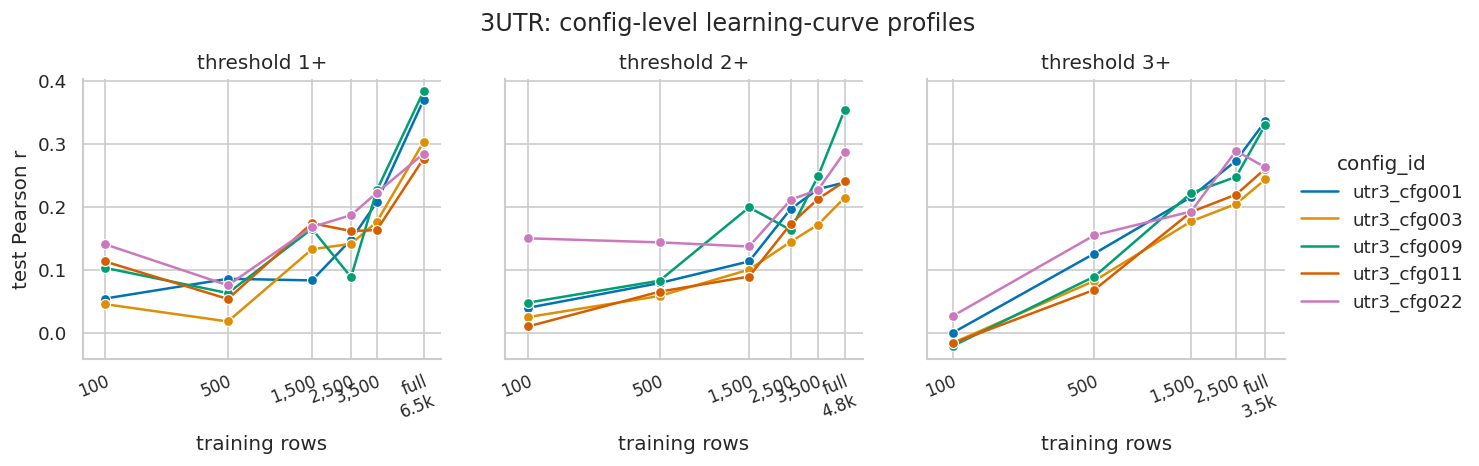

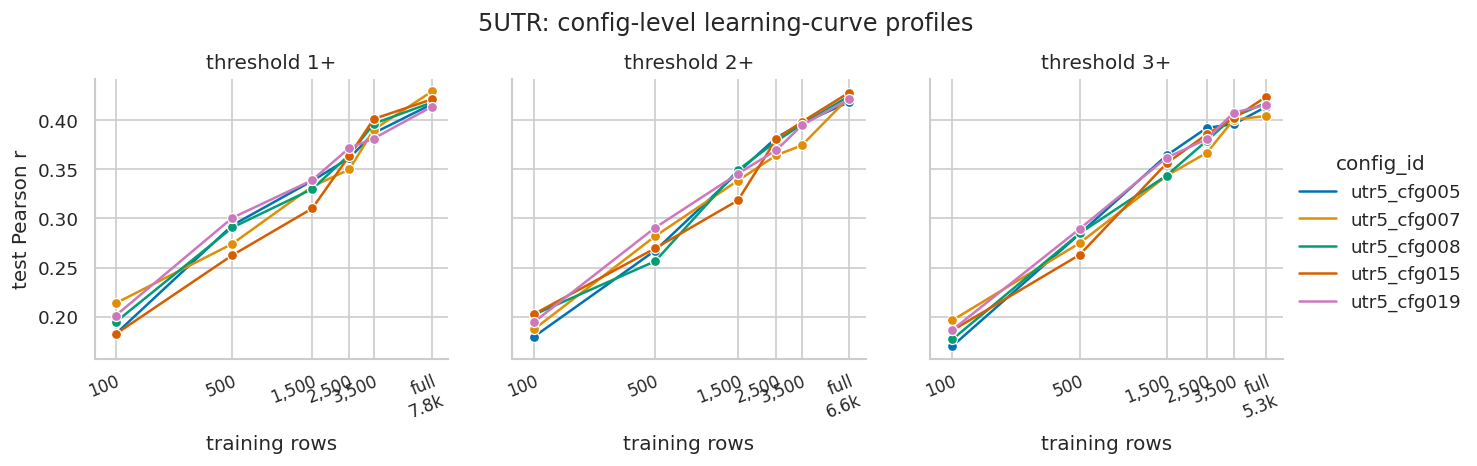

In [12]:
profile_df = runs[np.isfinite(pd.to_numeric(runs.get("test_pearson"), errors="coerce"))].copy()
if require_rows(profile_df, "config-level profiles"):
    for part in profile_df["part"].dropna().astype(str).unique():
        sub = profile_df[profile_df["part"].astype(str).eq(part)].copy()
        g = sns.relplot(
            data=sub,
            x="train_size_x",
            y="test_pearson",
            hue="config_id",
            col="threshold_display",
            kind="line",
            marker="o",
            estimator="mean",
            errorbar=None,
            height=3.4,
            aspect=1.08,
            facet_kws={"sharex": False, "sharey": True},
        )
        for ax, threshold in zip(g.axes.flat, facet_values(g, "col")):
            apply_size_axis(ax, sub[sub["threshold_display"].astype(str).eq(threshold)])
        g.set_ylabels("test Pearson r")
        g.set_titles("threshold {col_name}")
        g.fig.suptitle(f"{part}: config-level learning-curve profiles", y=1.05)
        finalize_facet_grid(g)
        if SAVE_FIGURES:
            g.fig.savefig(FIG_DIR / f"{part}_config_level_profiles.png", bbox_inches="tight", dpi=180)
        plt.show()


## Save Compact Analysis Tables

These CSVs are intentionally compact and can be used by downstream plotting/reporting scripts.


In [13]:
progress.to_csv(TABLE_DIR / "progress_by_part.csv", index=False)
runs.to_csv(TABLE_DIR / "completed_runs_for_current_analysis_parts.csv", index=False)
threshold_size_summary.to_csv(TABLE_DIR / "threshold_size_endpoint_summary.csv", index=False)
threshold_deltas.to_csv(TABLE_DIR / "paired_threshold_deltas_test_pearson.csv", index=False)
threshold_delta_summary.to_csv(TABLE_DIR / "paired_threshold_delta_summary_test_pearson.csv", index=False)
size_gains.to_csv(TABLE_DIR / "training_size_marginal_gains_test_pearson.csv", index=False)
size_gain_summary.to_csv(TABLE_DIR / "training_size_marginal_gain_summary_test_pearson.csv", index=False)
full_delta.to_csv(TABLE_DIR / "full_minus_best_exact_test_pearson.csv", index=False)
full_delta_summary.to_csv(TABLE_DIR / "full_minus_best_exact_summary_test_pearson.csv", index=False)
epoch_summary.to_csv(TABLE_DIR / "best_epoch_summary.csv", index=False)

print("Wrote analysis tables to:", TABLE_DIR)
print("Wrote figures to:", FIG_DIR if SAVE_FIGURES else "SAVE_FIGURES=False")


Wrote analysis tables to: /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretrain_CRE_inhouse_data/plots/lib1_barcode_threshold_downsample_june2026/tables
Wrote figures to: /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretrain_CRE_inhouse_data/plots/lib1_barcode_threshold_downsample_june2026/figures


## Interpretation Prompts

Use these prompts as the run completes:

1. At fixed N, is `2+` or `3+` consistently above `1+`?
2. Does the best threshold change between small-N and full-pool regimes?
3. Does `full` beat the best exact-N arm, or does adding lower-quality rows saturate or hurt?
4. Are threshold deltas paired-consistent across configs and split seeds, or driven by one config?
5. Does Intron remain flatter than Promoter/UTRs, as suggested by the exact barcode-bin run?
6. Do train/test gaps grow at low thresholds or small N, suggesting overfit to noisy labels?
